# 미션 12

미션 소개<br/>
Hugging Face transformers 라이브러리를 사용하여 문서 요약 모델을 구현하는 미션입니다. 데이터 로드 및 전처리부터 요약 모델 실행, 결과 평가까지 전체 파이프라인을 구축해 보세요.

---

## Step 1: 데이터 로딩 및 기본 EDA

## 목표
- JSON 데이터 로드 및 구조 파악
- 데이터 전처리
- 기본적인 탐색적 데이터 분석 (EDA)
- 데이터 품질 확인

In [1]:
# 로컬에서 압축하기

import os
import zipfile
import unicodedata

# 검색할 키워드를 NFC와 NFD로 모두 설정 (Mac/Windows 호환)
search_keyword_nfc = unicodedata.normalize('NFC', '한영')
search_keyword_nfd = unicodedata.normalize('NFD', '한영')

def find_zip_with_keyword(search_dirs):
    """키워드가 포함된 zip 파일 찾기"""
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for fn in os.listdir(d):
            if not fn.endswith('.zip'):
                continue
            # NFC와 NFD 모두 검사 (Mac은 NFD, Windows는 NFC 사용)
            normalized_nfc = unicodedata.normalize('NFC', fn)
            normalized_nfd = unicodedata.normalize('NFD', fn)
            if (search_keyword_nfc in normalized_nfc) or (search_keyword_nfd in normalized_nfd):
                return os.path.join(d, fn)
    return None

def find_first_zip(search_dirs):
    """첫 번째 zip 파일 찾기"""
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for fn in os.listdir(d):
            if fn.endswith('.zip'):
                return os.path.join(d, fn), d
    return None, None

# 1. 압축 파일 경로 설정
search_dirs = ['.', './data']

# 우선 키워드로 검색
zip_file_path = find_zip_with_keyword(search_dirs)

if zip_file_path:
    print(f"키워드 '한영'이 포함된 zip 파일 발견: '{zip_file_path}'")
else:
    # 키워드 매칭 실패 시 첫 번째 zip 파일 사용
    zip_file_path, found_dir = find_first_zip(search_dirs)
    if zip_file_path:
        print(f"키워드 매칭된 파일이 없으므로 '{found_dir}'에서 첫 번째 zip 파일 사용: '{zip_file_path}'")

# 2. 압축 해제
if zip_file_path is None:
    print("오류: 압축 파일(.zip)을 찾을 수 없습니다. 현재 디렉토리 또는 './data'에 .zip 파일이 있는지 확인하세요.")
else:
    # 압축 해제할 경로
    extract_path = './data'
    os.makedirs(extract_path, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"'{zip_file_path}' 파일이 '{extract_path}' 폴더에 성공적으로 압축 해제되었습니다.\n")
        print("압축 해제된 파일 목록:")
        for filename in os.listdir(extract_path):
            print(f" - {os.path.join(extract_path, filename)}")

    except FileNotFoundError:
        print(f"\n오류: '{zip_file_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")
    except Exception as e:
        print(f"\n오류: 압축 해제 중 문제가 발생했습니다. {e}")

키워드 매칭된 파일이 없으므로 './data'에서 첫 번째 zip 파일 사용: './data\summarization.zip'
'./data\summarization.zip' 파일이 './data' 폴더에 성공적으로 압축 해제되었습니다.

압축 해제된 파일 목록:
 - ./data\AIHub
 - ./data\summarization
 - ./data\summarization.zip


# 압축 해제 후 시작

In [1]:
# 2. 라이브러리 임포트
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import platform
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

# seaborn 스타일 먼저 설정
sns.set_style('whitegrid')

# 한글 폰트 설정 (Windows/Mac/Linux 호환)
system = platform.system()
if system == 'Windows':
    font_name = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    font_name = 'AppleGothic'
else:  # Linux
    font_name = 'NanumGothic'

# 폰트 직접 설정 (캐시 문제 해결)
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# 설정 확인
print(f"라이브러리 임포트 완료! (폰트: {font_name})")

라이브러리 임포트 완료! (폰트: Malgun Gothic)


## 2. 데이터 로드

In [2]:
# 모든 데이터 파일 로드
import json
from pathlib import Path

data_dir = Path('./data/summarization')

# 파일 경로 설정
file_paths = {
    'train': {
        'news': data_dir / 'train_original_news.json',
        'editorial': data_dir / 'train_original_editorial.json',
        'law': data_dir / 'train_original_law.json'
    },
    'valid': {
        'news': data_dir / 'valid_original_news.json',
        'editorial': data_dir / 'valid_original_editorial.json',
        'law': data_dir / 'valid_original_law.json'
    }
}

# 데이터 로드 함수
def load_json_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# 모든 데이터 로드
print("=" * 60)
print("데이터 로딩 중...")
print("=" * 60)

all_data = {}
for split in ['train', 'valid']:
    all_data[split] = {}
    for domain, path in file_paths[split].items():
        print(f"\n{split.upper()} - {domain.upper()} 로딩 중...")
        data = load_json_data(path)
        all_data[split][domain] = data
        print(f"  ✓ 프로젝트명: {data['name']}")
        print(f"  ✓ 배포일: {data['delivery_date']}")
        print(f"  ✓ 문서 수: {len(data['documents']):,}개")

print("\n" + "=" * 60)
print("모든 데이터 로드 완료!")
print("=" * 60)

데이터 로딩 중...

TRAIN - NEWS 로딩 중...
  ✓ 프로젝트명: 문서요약 프로젝트
  ✓ 배포일: 2020-12-23 12:01:15
  ✓ 문서 수: 243,983개

TRAIN - EDITORIAL 로딩 중...
  ✓ 프로젝트명: 사설/잡지 문서 프로젝트
  ✓ 배포일: 2020-12-23 15:00:19
  ✓ 문서 수: 56,760개

TRAIN - LAW 로딩 중...
  ✓ 프로젝트명: 법률문서 프로젝트
  ✓ 배포일: 2020-12-23 17:23:13
  ✓ 문서 수: 24,329개

VALID - NEWS 로딩 중...
  ✓ 프로젝트명: 문서요약 프로젝트
  ✓ 배포일: 2020-12-23 12:01:15
  ✓ 문서 수: 30,122개

VALID - EDITORIAL 로딩 중...
  ✓ 프로젝트명: 사설/잡지 문서 프로젝트
  ✓ 배포일: 2020-12-23 15:00:19
  ✓ 문서 수: 7,008개

VALID - LAW 로딩 중...
  ✓ 프로젝트명: 법률문서 프로젝트
  ✓ 배포일: 2020-12-23 17:23:13
  ✓ 문서 수: 3,004개

모든 데이터 로드 완료!


## 3. 데이터 구조 탐색

In [3]:
# 단일 문서 구조 확인 (각 도메인별 첫 번째 문서)
print("=" * 60)
print("각 도메인별 문서 구조 확인")
print("=" * 60)

domains = {
    'news': f'{data_dir}/train_original_news.json',
    'editorial': f'{data_dir}/train_original_editorial.json',
    'law': f'{data_dir}/train_original_law.json'
}

all_keys = {}

for domain, path in domains.items():
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 첫 번째 문서의 키
    doc = data['documents'][0]
    keys = set(doc.keys())
    all_keys[domain] = keys
    
    print(f"\n[{domain.upper()}] 키 목록 ({len(keys)}개):")
    print(f"  {sorted(keys)}")


각 도메인별 문서 구조 확인

[NEWS] 키 목록 (14개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'media_name', 'media_sub_type', 'media_type', 'publish_date', 'size', 'text', 'title']

[EDITORIAL] 키 목록 (14개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'media_name', 'media_sub_type', 'media_type', 'publish_date', 'size', 'text', 'title']

[LAW] 키 목록 (11개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'publish_date', 'size', 'text', 'title']


In [5]:
# 공통 키와 개별 키 분석
print("=" * 60)
print("키 비교 분석")
print("=" * 60)

# 모든 도메인의 공통 키
common_keys = set.intersection(*all_keys.values())
print(f"\n공통 키 목록 ({len(common_keys)}개):")
print(f"  {sorted(common_keys)}")

키 비교 분석

공통 키 목록 (11개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'publish_date', 'size', 'text', 'title']


`[LAW]` 키가 공통 키 목록과 동일해 보이지만 한번 더 확인하겠습니다.

In [6]:
# 각 도메인에만 있는 키
for domain, key in all_keys.items():
    unique_keys = key - common_keys
    if unique_keys:
        print(f"[{domain.upper()}]에만 있는 키 ({len(unique_keys)}개):")
        print(f"  {sorted(unique_keys)}")

[NEWS]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']
[EDITORIAL]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']


`[NEWS]`와 `[EDITORIAL]`에만 있는 키와 `[LAW]`에만 없는 키를 알아봅시다.

In [8]:
# NEWS와 EDITORIAL에만 있는 키
news_editorial_only = (all_keys['news']& all_keys['editorial']) - all_keys['law']
if news_editorial_only:
    print(f"[NEWS]와 [EDITORIAL]에만 있는 키 ({len(news_editorial_only)}개):")
    print(f"  {sorted(news_editorial_only)}")
    
# LAW 에만 없는 키
law_missing_keys = (all_keys['news'] | all_keys['editorial']) - all_keys['law']
if law_missing_keys:
    print(f"\n[LAW]에만 없는 키 ({len(law_missing_keys)}개):")
    print(f"  {sorted(law_missing_keys)}")

[NEWS]와 [EDITORIAL]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']

[LAW]에만 없는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']


문서별로 키를 알았으니 공통 키를 기반으로 샘플을 확인하겠습니다.

In [9]:
# 도메인별 샘플 문서 출력
print("=" * 60)
print("도메인별 샘플 문서 확인")
print("=" * 60)

# unique_keys 를 이용하여 공통 기반 샘플 확인

for domain, path in domains.items():
    print(f"\n{'='*40}\n[{domain.upper()}] 샘플 문서 키-값 쌍\n{'='*40}")
    sample_doc = all_data['train'][domain]['documents'][0]
    
    # 공통 키 출력
    print(f"\n[공통 키 정보] ({len(common_keys)}개):")
    # print(f"{common_keys}")
    # {'document_quality_scores', 'text', 'category', 'size', 'id', 'abstractive',
    # 'publish_date', 'title', 'extractive', 'char_count', 'annotator_id'}
    print(f"  - 문서 품질 점수: {sample_doc.get('document_quality_scores', 'N/A')}")
    # print(f"  - 본문: {sample_doc.get('text', 'N/A')[:50]}...")
    print(f"  - 카테고리: {sample_doc.get('category', 'N/A')}")
    print(f"  - 크기: {sample_doc.get('size', 'N/A')}")
    print(f"  - 문서 ID: {sample_doc.get('id', 'N/A')}")
    # print(f"  - 생성 요약: {sample_doc.get('abstractive', 'N/A')}")
    print(f"  - 발행일: {sample_doc.get('publish_date', 'N/A')}")
    print(f"  - 제목: {sample_doc.get('title', 'N/A')}")
    # print(f"  - 추출: {sample_doc.get('extractive', 'N/A')}")
    print(f"  - 문자 수: {sample_doc.get('char_count', 'N/A')}")
    print(f"  - 작성자 ID: {sample_doc.get('annotator_id', 'N/A')}")
    
    # 텍스트 구조 확인
    if 'text' in sample_doc:
        text_structure = sample_doc['text']
        print(f"  - 텍스트 단락 수: {len(text_structure)}개")
        if len(text_structure) > 0 and len(text_structure[0]) > 0:
            print(f"  - 첫 문장 예시: {text_structure[0][0].get('sentence', 'N/A')[:50]}...")
    
    # 요약 정보 확인
    if 'extractive' in sample_doc:
        print(f"  - 추출 요약 문장 수: {len(sample_doc['extractive'])}개")
    if 'abstractive' in sample_doc:
        print(f"  - 생성 요약: {sample_doc['abstractive'][:50]}...")

도메인별 샘플 문서 확인

[NEWS] 샘플 문서 키-값 쌍

[공통 키 정보] (11개):
  - 문서 품질 점수: {'readable': 4, 'accurate': 3, 'informative': 3, 'trustworthy': 3}
  - 카테고리: 종합
  - 크기: small
  - 문서 ID: 290741778
  - 발행일: 2018-01-05 18:54:55
  - 제목: 논 타작물 재배, 2월 말까지 신청하세요
  - 문자 수: 927
  - 작성자 ID: 11
  - 텍스트 단락 수: 11개
  - 첫 문장 예시: ha당 조사료 400만원…작물별 차등 지원...
  - 추출 요약 문장 수: 3개
  - 생성 요약: ["전라남도가 쌀 과잉문제를 근본적으로 해결하기 위해 올해부터 벼를 심었던 논에 벼 대신 사료작물이나 콩 등 다른 작물을 심으면 벼와의 일정 소득차를 보전해주는 '쌀 생산조정제'를 적극적으로 시행하기로 하고 오는 22일부터 2월 28일까지 농지 소재지 읍면동사무소에서 신청받는다 ."]...

[EDITORIAL] 샘플 문서 키-값 쌍

[공통 키 정보] (11개):
  - 문서 품질 점수: {'readable': 4, 'accurate': 3, 'informative': 3, 'trustworthy': 3}
  - 카테고리: 오피니언
  - 크기: medium
  - 문서 ID: 100062073
  - 발행일: 2011-09-01 00:03:01
  - 제목: [사설] 기부문화 확산 은근히 강조한 李대통령
  - 문자 수: 1153
  - 작성자 ID: 3924
  - 텍스트 단락 수: 5개
  - 첫 문장 예시: 이명박 대통령이 어제 30대 그룹 총수를 모아놓고 "시대적 요구는 역시 총수가 앞장서야 한...
  - 추출 요약 문장 수: 3개
  - 생성 요약: ['이명박 대통령은 어제 30대 그룹 총수를 모아놓고 시대적 요구는 역시 총수가 앞장서야 한다고 발언하며 기부문화 확산을 은근히 강조했으나 대통령의 강요나 포퓰리즘에 의한

## 4. 데이터 통계 요약

In [7]:
# 전체 데이터 통계 요약 테이블 생성
import pandas as pd

summary_stats = []

for split in ['train', 'valid']:
    for domain in domains:
        docs = all_data[split][domain]['documents']
        # print(f"\n{split.upper()} - {domain.upper()} : {len(docs):,}개 문서")
        summary_stats.append({
            '분할' : split.upper(),
            '도메인' : domain.upper(),
            '문서_갯수' : len(docs)
        })
        
summary_df = pd.DataFrame(summary_stats)

In [11]:
# 전체 데이터 통계 요약
print("\n" + "=" * 60)
print("데이터셋 규모 요약")
print("=" * 60)

# 피벗 테이블 정리
pivot_df = summary_df.pivot(index='도메인', columns='분할', values='문서_갯수')
pivot_df['Total'] = pivot_df['TRAIN'] + pivot_df['VALID']
pivot_df['Valid Ratio (%)'] = (pivot_df['VALID'] / pivot_df['Total'] * 100).round(2)

styled_df = pivot_df.style.set_properties(**{'text-align': 'center'}).format({
    'TRAIN': '{:,.0f}',
    'VALID': '{:,.0f}',
    'Total': '{:,.0f}',
    'Valid Ratio (%)': '{:.2f}'
})
display(styled_df)

print(f"\n전체 Train 문서 수 : {pivot_df['TRAIN'].sum(): ,}개")
print(f"전체 Valid 문서 수 : {pivot_df['VALID'].sum(): ,}개")
print(f"전체 문서 수: {pivot_df['Total'].sum(): ,}개")


데이터셋 규모 요약


분할,TRAIN,VALID,Total,Valid Ratio (%)
도메인,,,,
EDITORIAL,"56,760","7,008","63,768",10.99
LAW,"24,329","3,004","27,333",10.99
NEWS,"243,983","30,122","274,105",10.99



전체 Train 문서 수 :  325,072개
전체 Valid 문서 수 :  40,134개
전체 문서 수:  365,206개


## 5. 도메인별 데이터 분포 시각화

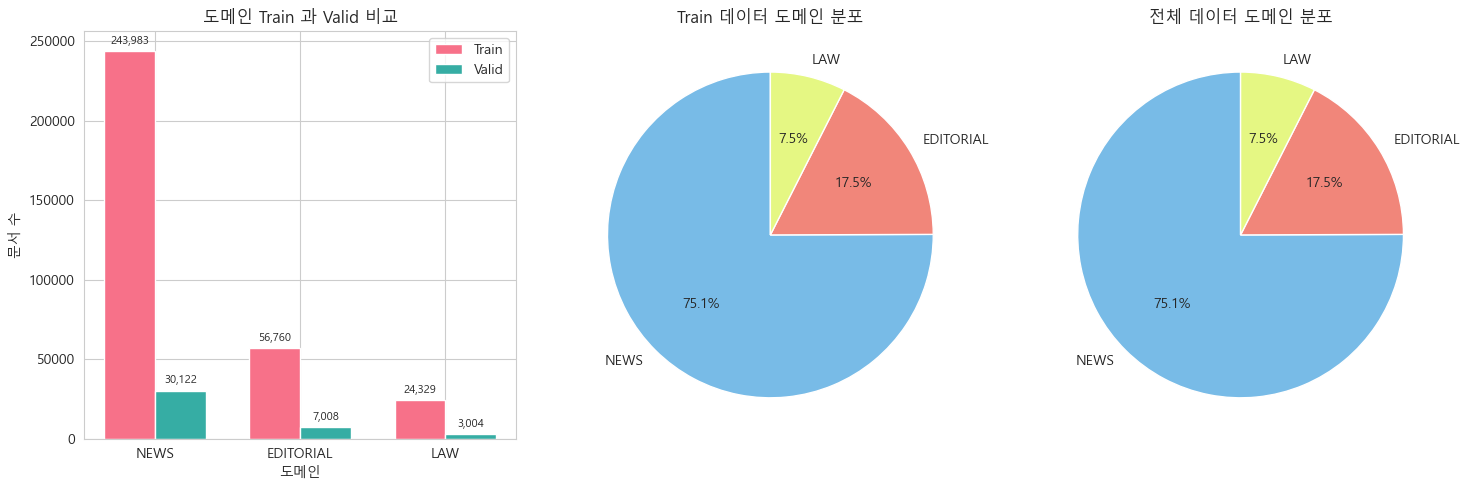

In [12]:
# 도메인별 데이터 분포 시각화
fig, axes = plt.subplots(1,3,figsize=(15,5))

# 1. 도메인별 문서 수 ('Train' vs 'Valid')
domains = [d.upper() for d in all_keys.keys()]
train_counts = [pivot_df.loc[d, 'TRAIN'] for d in domains]
valid_counts = [pivot_df.loc[d, 'VALID'] for d in domains]

x = np.arange(len(domains))
width = 0.35

colors = sns.color_palette('husl', 2) 

bars1 = axes[0].bar(x-width/2, train_counts, width, label='Train', color=colors[0])
bars2 = axes[0].bar(x+width/2, valid_counts, width, label='Valid', color=colors[1])
axes[0].set_xlabel('도메인')
axes[0].set_ylabel('문서 수')
axes[0].set_title('도메인 Train 과 Valid 비교')
axes[0].set_xticks(x)
axes[0].set_xticklabels(domains)
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')

# 막대 위에 숫자 표시
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f"{int(height):,}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0,3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=8)
    
for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0,3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=8)
    
# 2. Train 데이터 도메인 비율 (Pie chart)
colors = ["#78bbe7", "#f1867a", "#e5f783"]
axes[1].pie(train_counts, labels=domains, autopct='%1.1f%%', colors=colors,startangle=90)
axes[1].set_title('Train 데이터 도메인 분포')

# 3. 전체 데이터 도메인 비율 (Pie chart)
total_counts = [t + v for t, v in zip(train_counts, valid_counts)]
axes[2].pie(total_counts, labels=domains, autopct='%1.1f%%', colors=colors, startangle=90)
axes[2].set_title('전체 데이터 도메인 분포')

plt.tight_layout()
plt.show()

`[NEWS]` 데이터가 약 75%로 가장 많음

`[LAW]` 데이터가 가장 적음 (약 7.5%)

학습 시 도메인 불균형 처리가 필요한것으로 보입니다.

## 6. 텍스트 길이 분석

In [8]:
# 텍스트 추출 및 길이 계산 함수
import numpy as np
def extract_full_text(doc):
    """문서에서 전체 텍스트를 추출"""
    sentences = []
    if 'text' in doc:
        for paragraph in doc['text']:
            for sent_obj in paragraph:
                if isinstance(sent_obj, dict) and 'sentence' in sent_obj:
                    sentences.append(sent_obj['sentence'])
    return ' '.join(sentences)

def get_abstractive_summary(doc):
    """생성 요약 추출"""
    abstractive  = doc.get('abstractive')
    
    # 리스트인 경우 문자열로 합치기
    if isinstance(abstractive, list):
        return ' '.join(abstractive)
    
    return abstractive if abstractive else ""

def get_extractive_summary(doc):
    """추출 요약 추출 (문장 인덱스 기반)"""
    if 'extractive' not in doc:
        return ''
    
    extractive_indices = doc['extractive']
    sentences = []
    if 'text' in doc:
        all_sentences = []
        for paragraph in doc['text']:
            for sent_obj in paragraph:
                if isinstance(sent_obj, dict) and 'sentence' in sent_obj:
                    all_sentences.append(sent_obj['sentence'])
                    
        for idx in extractive_indices:
            if idx < len(all_sentences):
                sentences.append(all_sentences[idx])
                
    return ' '.join(sentences)

# Train 데이터에서 텍스트 길이 분석
print("텍스트 길이 분석 중 .. (시간이 걸릴 수 있습니다)")

length_data = []

for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    # 샘플링
    sample_size = min(10000, len(docs))
    sampled_docs = np.random.choice(docs,sample_size, replace=False)
    
    for doc in sampled_docs:
        full_text = extract_full_text(doc)
        abstractive = get_abstractive_summary(doc)
        
        length_data.append({
            'domain':domain.upper(),
            'text' : full_text,
            'summary' : abstractive,
            'text_length' : len(full_text),
            'text_word_count' : len(full_text.split()),
            'abstractive_length': len(abstractive),
            'char_count': int(doc.get('char_count',0)) if doc.get('char_count') else 0,
            'size' : doc.get('size', 'unknown')
        })
        
length_df = pd.DataFrame(length_data)
print("✓ 텍스트 길이 분석 완료!")

텍스트 길이 분석 중 .. (시간이 걸릴 수 있습니다)
✓ 텍스트 길이 분석 완료!


1. `extract_full_text(doc)` : 전체 텍스트 추출

왜 만들었나? <br/>
- 데이터 구조가 `doc['text'] -> 문단들 -> 문장 객체들 -> {'sentence': '실제 문장'}` 형태로 중첩되어 있음
- 이 복잡한 구조에서 **모든 문장을 하나의 문자열로 합쳐서** 텍스트 길이를 측정하기 위함

---

2. `get_abstractive_summary(doc)` : 생성 요약 추출

왜 만들었나? <br/>
- **생성요약(Abstractive)** : 원문을 새로운 문장으로 재작성한 요약
- `doc['abstractive']` 값이 **리스트 형태** 이므로 문자열로 변환 필요
- 리스트인 경우 `' '.join()` 으로 합치고, 없으면 빈 문자열 반환
- 요약문 길이를 원문과 비교 분석하기 위함

---

3. `get_extractive_summary(doc)` : 추출 요약 추출

왜 만들었나? <br/>
- **추출 요약(Extractive)** : 원문에서 중요한 문장을 **그대로 뽑아내는** 방식
- 데이터에는 문장 자체가 아니라 **문장 인덱스 번호**만 저장되어 있음 (예 : [0,3,5])
- 이 인덱스를 실제 문장으로 변환하기 위해 필요

---

4. 길이 분석 루프 + 샘플링

왜 만들었나? <br/>
- **도메인별 텍스트 특성 비교** : 뉴스 / 사설 / 법률 문서의 길이가 얼마나 다른지
- **압축률 분석** : 원문 대비 요약이 얼마나 짧은지
- **모델 설계 참고** : 입력 최대 길이(max_length) 설정 시 참고

---

이 분석 결과(`length_df`) 를 통해 **토크나이저 설정, 모델 입력 길이, 도메인 별 특성**을 파악할 수 있습니다.

In [14]:
# 도메인별 텍스트 길이 통계
print("=" * 60)
print("도메인별 텍스트 길이 통계")
print("=" * 60)

# 통계 계산
stats_df = length_df.groupby('domain').agg({
    'text_length' : ['mean', 'std', 'min', 'max', 'median'],
    'abstractive_length' : ['mean', 'std', 'min', 'max', 'median']
}).round(1)

# MultiIndex 컬럼을 단일 컬럼으로 평탄화
stats_df.columns = ['_'.join(col) for col in stats_df.columns]
stats_df = stats_df.reset_index()

# 원문 텍스트 길이 테이블
print("\n[원문 텍스트 길이 (문자 수)]")
# print(stats_df['text_length'].to_string())
text_cols = ['domain', 'text_length_mean', 'text_length_std', 'text_length_min', 'text_length_max', 'text_length_median']
text_df = stats_df[text_cols].copy()
text_df.columns = ['도메인', '평균', '표준편차', '최소', '최대', '중앙값']


# 도메인 제외한 모든 컬럼에 포맷 적용
styled_text = text_df.style.set_properties(**{'text-align': 'center'}).format(
    '{:,.1f}', 
    subset=['평균', '표준편차', '최소', '최대', '중앙값']
).hide(axis='index')

display(styled_text)

print("\n[생성 요약 길이 (문자 수)]")
# print(stats_df['abstractive_length'].to_string())
abs_cols = ['domain', 'abstractive_length_mean', 'abstractive_length_std', 'abstractive_length_min', 'abstractive_length_max', 'abstractive_length_median']
abs_df = stats_df[abs_cols].copy()
abs_df.columns = ['도메인', '평균', '표준편차', '최소', '최대', '중앙값']
# 도메인 제외한 모든 컬럼에 포맷 적용
styled_abs  = abs_df.style.set_properties(**{'text-align': 'center'}).format(
    '{:,.1f}', 
    subset=['평균', '표준편차', '최소', '최대', '중앙값']
).hide(axis='index')


display(styled_abs)

# 압축률 계산
print("\n[평균 압축률 (요약/원문)]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]
    avg_text = domain_data['text_length'].mean()
    avg_summary= domain_data['abstractive_length'].mean()
    compression = (avg_summary / avg_text * 100) if avg_summary > 0 else 0
    print(f"    {domain}: {compression:.1f}%")

도메인별 텍스트 길이 통계

[원문 텍스트 길이 (문자 수)]


도메인,평균,표준편차,최소,최대,중앙값
EDITORIAL,"1,172.3",242.1,114.0,"1,931.0","1,136.0"
LAW,666.5,444.8,81.0,"3,993.0",539.0
NEWS,"1,011.6",296.7,487.0,"1,967.0",936.0



[생성 요약 길이 (문자 수)]


도메인,평균,표준편차,최소,최대,중앙값
EDITORIAL,122.3,33.7,19.0,397.0,120.0
LAW,197.9,77.8,33.0,993.0,187.0
NEWS,128.5,35.9,0.0,392.0,125.0



[평균 압축률 (요약/원문)]
    NEWS: 12.7%
    EDITORIAL: 10.4%
    LAW: 29.7%


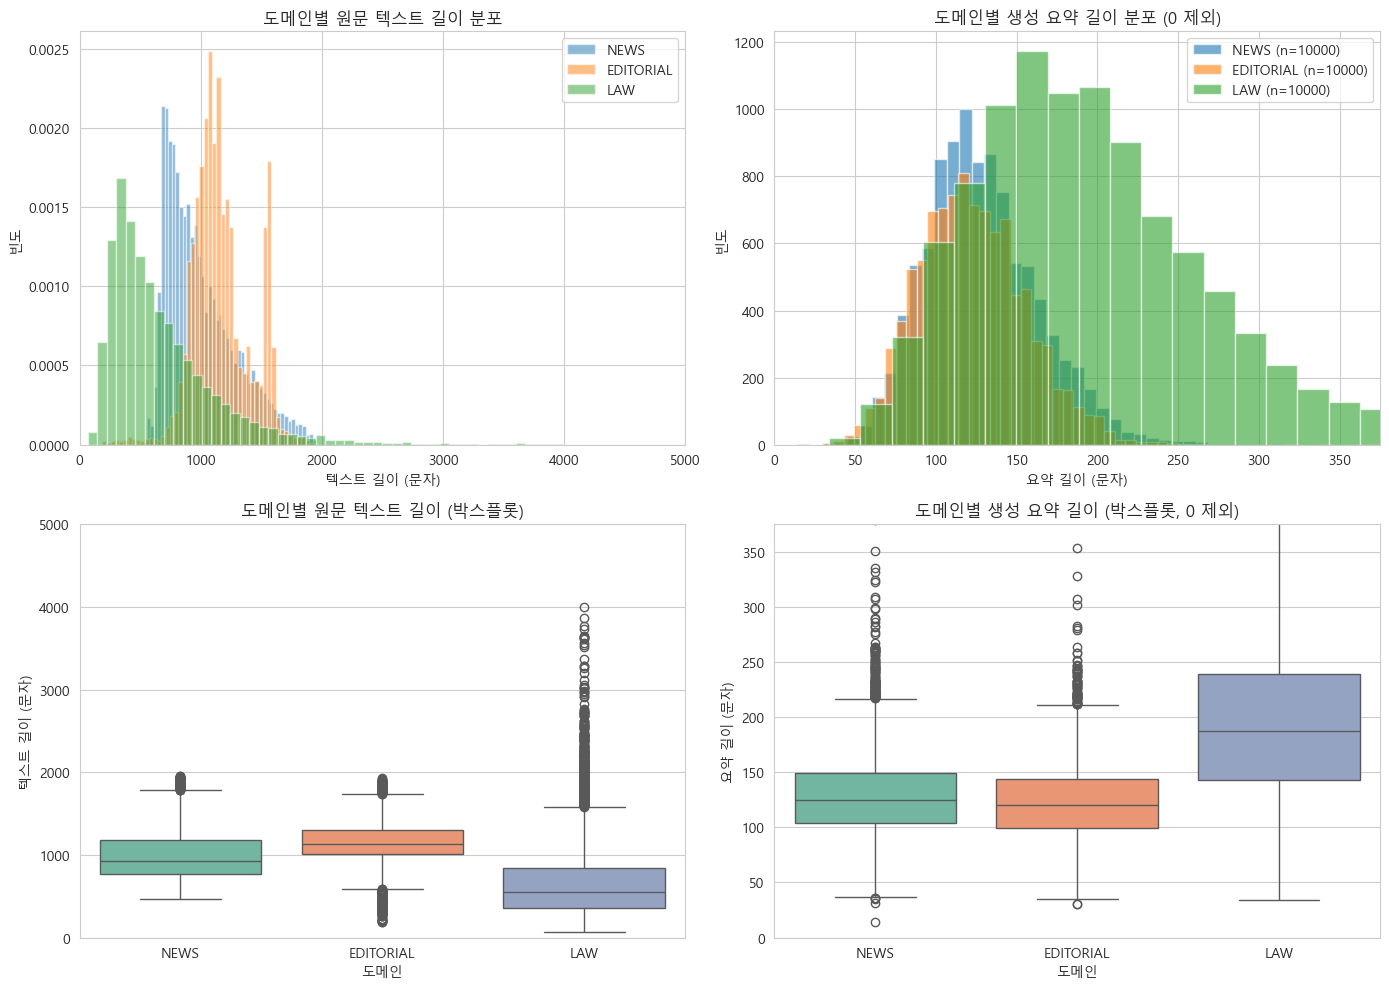

In [22]:
# 텍스트 길이 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 도메인별 원문 텍스트 길이 분포 (히스토그램)
for domain in domains:
    domain_data = length_df[length_df['domain'] == domain]['text_length']
    axes[0, 0].hist(domain_data, bins=50, alpha=0.5, label=domain, density=True)
axes[0, 0].set_xlabel('텍스트 길이 (문자)')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].set_title('도메인별 원문 텍스트 길이 분포')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 5000)

# 2. 도메인별 요약 길이 분포 (히스토그램) - 0보다 큰 값만 필터링
for domain in domains:
    domain_data = length_df[(length_df['domain'] == domain) & (length_df['abstractive_length'] > 0)]['abstractive_length']
    if len(domain_data) > 0:
        axes[0, 1].hist(domain_data, bins=50, alpha=0.6, label=f"{domain} (n={len(domain_data)})")
axes[0, 1].set_xlabel('요약 길이 (문자)')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title('도메인별 생성 요약 길이 분포 (0 제외)')
axes[0, 1].legend()
# xlim 자동 설정 (데이터 기반)
valid_abstractive = length_df[length_df['abstractive_length'] > 0]['abstractive_length']
if len(valid_abstractive) > 0:
    axes[0, 1].set_xlim(0, valid_abstractive.quantile(0.99))

# 3. 도메인별 원문 길이 박스플롯
sns.boxplot(data=length_df, x='domain', y='text_length', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_xlabel('도메인')
axes[1, 0].set_ylabel('텍스트 길이 (문자)')
axes[1, 0].set_title('도메인별 원문 텍스트 길이 (박스플롯)')
axes[1, 0].set_ylim(0, 5000)

# 4. 도메인별 요약 길이 박스플롯 - 0보다 큰 값만 필터링
valid_df = length_df[length_df['abstractive_length'] > 0]
if len(valid_df) > 0:
    sns.boxplot(data=valid_df, x='domain', y='abstractive_length', ax=axes[1, 1], palette='Set2')
    axes[1, 1].set_ylim(0, valid_df['abstractive_length'].quantile(0.99))
else:
    axes[1, 1].text(0.5, 0.5, '유효한 요약 데이터 없음', ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 1].set_xlabel('도메인')
axes[1, 1].set_ylabel('요약 길이 (문자)')
axes[1, 1].set_title('도메인별 생성 요약 길이 (박스플롯, 0 제외)')

plt.tight_layout()
plt.show()

`[분석 포인트]`

1. `[NEWS]` 도메인
> 텍스트 길이 분산이 커서 문서 길이의 이질성이 높은 편이다.

2. `[EDITORIAL]` 도메인
> 원문 길이는 가장 길지만, 생성 요약 길이는 LAW 보다는 작은 경향이 보인다.

3. `[LAW]` 도메인
> 중앙값 기준으로 원문 길이가 가장 짧지만, 긴 문서가 많이 포함되어 분산과 이상치가 큰 편이다.

## 7. 카테고리 분석

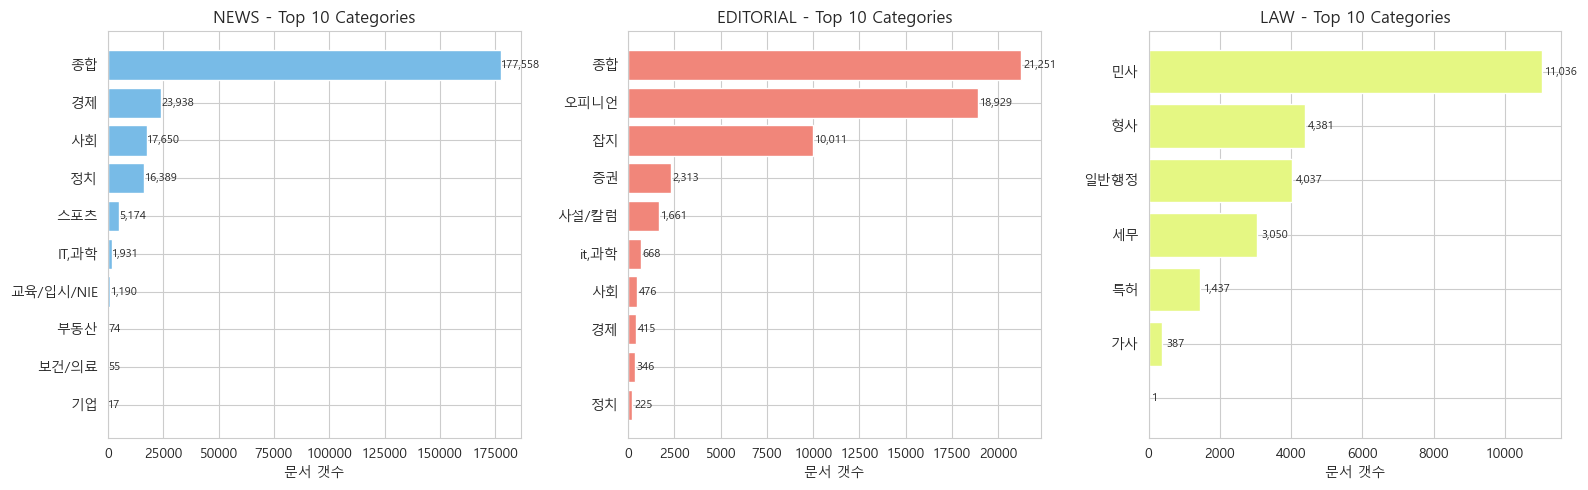

In [10]:
# 도메인별 카테고리 분포 분석
fig, axes = plt.subplots(1,3, figsize=(16,5))
colors = ["#78bbe7", "#f1867a", "#e5f783"]


for idx, domain in enumerate(all_data['train'].keys()):
    docs = all_data['train'][domain]['documents']
    categories = [doc.get('category', 'Unknown') for doc in docs]
    category_counts = pd.Series(categories).value_counts().head(10)
    
    # 카테고리가 없는 경우 대비
    if not category_counts.empty:
        bars = axes[idx].barh(category_counts.index, category_counts.values, color=colors[idx])
        axes[idx].set_xlabel('문서 갯수')
        axes[idx].set_title(f'{domain.upper()} - Top 10 Categories')
        axes[idx].invert_yaxis()
    
        # 숫자 표시
        for bar, count in zip(bars, category_counts.values):
            axes[idx].text(bar.get_width() + 100 , bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=8)
            
          
    else:
        axes[idx].set_title(f'{domain.upper()} - 카테고리 찾지 못하였습니다.')
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        
plt.tight_layout()
plt.show()

In [10]:
# 각 도메인별 카테고리 수
print("\n[도메인별 고유 카테고리 수]")
for domain in all_data['train'].keys():
    docs = all_data['train'][domain]['documents']
    categories = set(doc.get('category', 'Unknown') for doc in docs)
    print(f"  {domain.upper()}: {len(categories)}개")


[도메인별 고유 카테고리 수]
  NEWS: 12개
  EDITORIAL: 32개
  LAW: 7개


## 8. 문서 크기(size) 분포 분석

In [6]:
# 전체 size 분포
size_data = []
for domain in all_data['train'].keys():
    docs = all_data['train'][domain]['documents']
    for doc in docs:
        size_data.append({
            'domain' : domain.upper(),
            'size' : doc.get('size', 'unknown')
        })
        
size_df = pd.DataFrame(size_data)

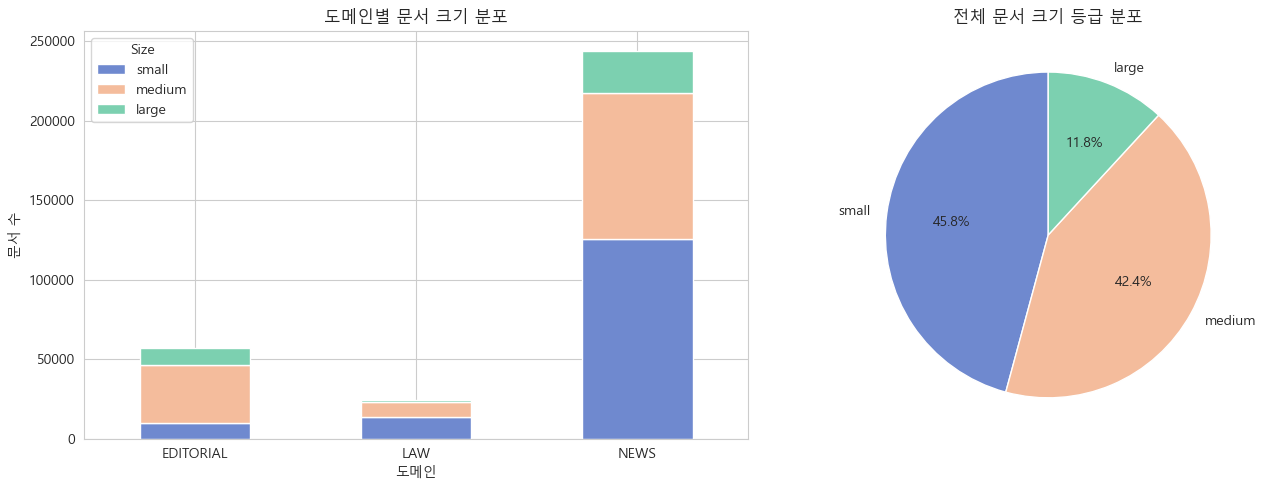

In [8]:
# 문서 크기(size) 분포 분석
fig, axes = plt.subplots(1,2, figsize=(14,5))
colors = ["#6f89cf", "#f4bc9c", "#7cd0b0"]

# 1. 도메인별 size 분포 (Stacked Bar)
size_order = ['small', 'medium', 'large']
size_pivot = pd.crosstab(size_df['domain'], size_df['size'])

# size_order 에 있는 열만 선택 (없는 경우 대비)
available_sizes = [s for s in size_order if s in size_pivot.columns]
size_pivot = size_pivot[available_sizes]

size_pivot.plot(kind='bar', stacked=True, ax=axes[0], color=colors)
axes[0].set_xlabel('도메인')
axes[0].set_ylabel('문서 수')
axes[0].set_title('도메인별 문서 크기 분포')
axes[0].legend(title='Size')
axes[0].tick_params(axis='x', rotation=0)

# 2. 전체 비율 (Pie Chart)
total_size_counts = size_df['size'].value_counts()
# size_order 순서로 정렬
total_size_counts = total_size_counts.reindex([s for s in size_order if s in total_size_counts.index])
axes[1].pie(total_size_counts.values, labels=total_size_counts.index,
            autopct='%1.1f%%', colors=colors , startangle=90)
axes[1].set_title('전체 문서 크기 등급 분포')

plt.tight_layout()
plt.show()

In [10]:
# size 별 평균 문자 수
print("[Size별 평균 문자 수]")
size_char_data = []
for domain in all_data['train'].keys():
    docs = all_data['train'][domain]['documents']
    for doc in docs:
        char_count = doc.get('char_count', 0)
        if isinstance(char_count, str):
            char_count = int(char_count) if char_count.isdigit() else 0
        size_char_data.append({
            'size' : doc.get('size', 'unknown'),
            'char_count' : char_count
        })
        
size_char_df = pd.DataFrame(size_char_data)
print(size_char_df.groupby('size')['char_count'].agg(['mean', 'min', 'max']).round(0).to_string())

[Size별 평균 문자 수]
          mean   min   max
size                      
large   1667.0  1289  4005
medium  1178.0   600  1499
small    795.0    72   999


## 9. 요약 품질 점수 분석

요약 품질 점수 분석

[문서 품질 점수 (Document Quality Scores)]
           readable  accurate  informative  trustworthy
domain                                                 
EDITORIAL      3.67      3.67         3.43         3.63
LAW            3.89      3.89         3.42         4.09
NEWS           3.73      3.77         3.56         3.78


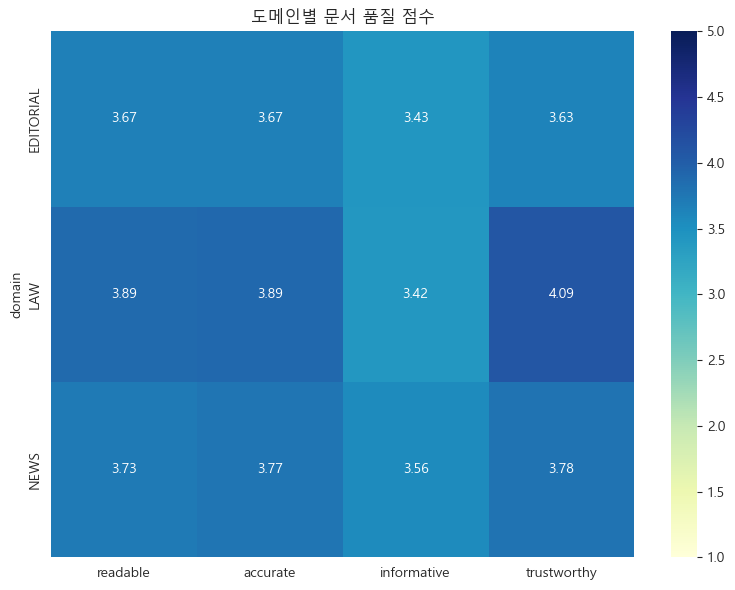

In [21]:
# 요약 품질 점수 분석 (document_quality_scores)
quality_data = []

for domain in all_data['train'].keys():
    docs = all_data['train'][domain]['documents']
    
    for doc in docs:
        # document_quality_scores 체크
        doc_quality = doc.get('document_quality_scores', {})
        #abs_quality = doc.get('abstractive_quality_scores', {}) # 그래프에 나오지 않아 다음 셀에서 확인
        
        if doc_quality: 
            quality_entry = {'domain': domain.upper()}
            
            # document_quality_scores
            for key in ['readable', 'accurate', 'informative', 'trustworthy']:
                quality_entry[f'doc_{key}'] = doc_quality.get(key, np.nan)
            
            quality_data.append(quality_entry)

if quality_data:
    quality_df = pd.DataFrame(quality_data)
    
    # 도메인별 품질 점수 평균
    print("=" * 60)
    print("요약 품질 점수 분석")
    print("=" * 60)
    
    # Document Quality Scores
    doc_cols = [c for c in quality_df.columns if c.startswith('doc_')]
    if any(quality_df[doc_cols].notna().any()):
        print("\n[문서 품질 점수 (Document Quality Scores)]")
        doc_quality_mean = quality_df.groupby('domain')[doc_cols].mean().round(2)
        doc_quality_mean.columns = [c.replace('doc_', '') for c in doc_quality_mean.columns]
        print(doc_quality_mean.to_string())
    
    # 시각화
    fig, ax = plt.subplots(1, 1, figsize=(8,6))
    
    # Document Quality 히트맵
    doc_heatmap_data = quality_df.groupby('domain')[doc_cols].mean()
    doc_heatmap_data.columns = [c.replace('doc_', '') for c in doc_heatmap_data.columns]
    
    sns.heatmap(doc_heatmap_data, annot=True, cmap='YlGnBu', ax=ax, vmin=1, vmax=5, fmt='.2f')
    ax.set_title('도메인별 문서 품질 점수')
    
    plt.tight_layout()
    plt.show()
else:
    print("품질 점수 데이터가 없습니다.")

In [24]:
# abstractive_quality_scores 가 있는 문서 갯수 확인
count = 0
for domain in all_data['train'].keys():
    for doc in all_data['train'][domain]['documents']:
        if doc.get('abstractive_quality_scores'):
            count += 1
             
print(f"abstractive_quality_scores가 있는 문서: {count}개")

abstractive_quality_scores가 있는 문서: 0개


## 10. 샘플 문서 확인

In [9]:
# 각 도메인에서 샘플 문서 확인
def display_sample_document(doc, domain):
    """샘플 문서를 보기 좋게 출력"""
    print(f"\n{'='*60}")
    print(f"[{domain.upper()} 샘플 문서]")
    print(f"{'='*60}")
    print(f"ID: {doc.get('id', 'N/A')}")
    print(f"제목: {doc.get('title', 'N/A')}")
    print(f"카테고리: {doc.get('category', 'N/A')}")
    print(f"크기: {doc.get('size', 'N/A')}")
    print(f"문자 수: {doc.get('char_count', 'N/A')}")
    
    # 원문 텍스트
    full_text = extract_full_text(doc)
    print(f"\n[원문] ({len(full_text)}자)")
    print("=" * 60)
    print(full_text[:500] + "..." if len(full_text) > 500 else full_text)
    
    # 생성 요약
    abstractive = doc.get('abstractive', '')
    if abstractive:
        print(f"\n[생성 요약 (Abstractive)] ({len(abstractive)}자)")
        print("=" * 60)
        print(abstractive)
    
    # 추출 요약 인덱스
    extractive = doc.get('extractive', [])
    if extractive:
        print(f"\n[추출 요약 인덱스 (Extractive)]")
        print("=" * 60)
        print(f"선택된 문장 인덱스: {extractive}")
        
        # 추출 요약 문장 출력
        extractive_text = get_extractive_summary(doc)
        print(f"\n[추출된 문장들]")
        print(extractive_text[:300] + "..." if len(extractive_text) > 300 else extractive_text)

In [14]:
# 각 도메인에서 1개씩 샘플 출력
for domain in ['news', 'editorial', 'law']:
    # medium 크기 문서 중에서 선택 (너무 짧거나 길지 않은)
    docs = all_data['train'][domain]['documents']
    medium_docs = [d for d in docs if d.get('size') == 'medium']
    if medium_docs:
        sample_doc = np.random.choice(medium_docs)
    else:
        sample_doc = docs[0]
    
    display_sample_document(sample_doc, domain)


[NEWS 샘플 문서]
ID: 344556694
제목: 대구시장 등 광역·기초단체장 대거 참석
카테고리: 정치
크기: medium
문자 수: 1153

[원문] (1120자)
9일 자유한국당 대구시당 강당에서 열린 ‘자유한국당 대구여성정치아카데미 개원식’에 참석한 관계자들이 행사가 끝난 뒤 기념촬영을 하고 있다. <자유한국당 대구시당 제공> 9일 열린 자유한국당 대구여성정치아카데미 제15기 개원식에 참석한 대구경북(TK) 정치인들이 현정부 성토에 열을 올리며 보수 결집을 촉구했다. 이날 오후 2시30분부터 한국당 대구시당 강당에서 열린 아카데미 개원식에는 곽대훈 대구시당 위원장(달서구갑)을 비롯해 김상훈(서구), 정종섭(동구갑), 추경호(달성), 김규환 의원(대구 동구을 지역위원장)과 정순천 대구 수성구갑 당협위원장 등이 참석했다. 또 권영진 대구시장을 비롯해 류규하 중구청장, 배기철 동구청장, 조재구 남구청장, 김대권 수성구청장 등 한국당 소속 단체장들과 배지숙 대구시의회 의장 및 한국당 소속 지방의원들도 대거 참석해 눈길을 끌었다. 곽대훈 위원장은 개원사에서 “위기를 위기라고 생각하지 않는 현 정부에 굉장히 실망하고 있다”며 “우리 한국당이 대한민국의...

[생성 요약 (Abstractive)] (1자)
['9일 오후 자유한국당 대구시당 강당에서 열린 대구여성 정치아카데미 제15기 개원식에 곽대훈 대구시당 위원장과 정순천 대구 수성구갑 당협위원장 외에도 권영진 대구시장과 배지숙 대구시의회 의장 등 한국당 소속 단체장·지방의원들이 대거 참석해 보수 결집을 촉구했다.']

[추출 요약 인덱스 (Extractive)]
선택된 문장 인덱스: [2, 3, 4]

[추출된 문장들]
9일 열린 자유한국당 대구여성정치아카데미 제15기 개원식에 참석한 대구경북(TK) 정치인들이 현정부 성토에 열을 올리며 보수 결집을 촉구했다. 이날 오후 2시30분부터 한국당 대구시당 강당에서 열린 아카데미 개원식에는 곽대훈 대구시당 위원장(달서구갑)을 비롯해 김상훈(서구), 정종섭(동

## 11. EDA 요약

In [29]:
# EDA 최종 요약
print("=" * 70)
print("                      EDA 최종 요약")
print("=" * 70)

print("\n[1. 데이터 규모]")
print(f"   - 전체 문서 수: {pivot_df['Total'].sum():,}개")
print(f"   - Train: {pivot_df['TRAIN'].sum():,}개 / Valid: {pivot_df['VALID'].sum():,}개")
print(f"   - Train:Valid 비율 = 약 89:11")

print("\n[2. 도메인 분포 (불균형)]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    total = pivot_df.loc[domain, 'Total']
    ratio = total / pivot_df['Total'].sum() * 100
    print(f"   - {domain}: {total:,}개 ({ratio:.1f}%)")

print("\n[3. 텍스트 길이 특성]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]
    avg_text = domain_data['text_length'].mean()
    avg_summary = domain_data['abstractive_length'].mean()
    print(f"   - {domain}: 원문 평균 {avg_text:.0f}자, 요약 평균 {avg_summary:.0f}자")

                      EDA 최종 요약

[1. 데이터 규모]
   - 전체 문서 수: 365,206개
   - Train: 325,072개 / Valid: 40,134개
   - Train:Valid 비율 = 약 89:11

[2. 도메인 분포 (불균형)]
   - NEWS: 274,105개 (75.1%)
   - EDITORIAL: 63,768개 (17.5%)
   - LAW: 27,333개 (7.5%)

[3. 텍스트 길이 특성]
   - NEWS: 원문 평균 1006자, 요약 평균 128자
   - EDITORIAL: 원문 평균 1172자, 요약 평균 122자
   - LAW: 원문 평균 673자, 요약 평균 199자


---

# Step 2: 상세 EDA 및 텍스트 분석

## 목표
- 심층적인 텍스트 분석
- 카테고리별 특성 분석
- 단어 및 문장 패턴 분석
- 데이터 인사이트 도출

## 1. 텍스트 통계 분석

In [10]:
# 단어 수 계산 함수
def count_word(text):
    """공백 기준으로 계산"""
    return len(text.split())

def count_unique_char(text):
    """고유 문자 수 계산"""
    return len(set(text))

def avg_word_text(text):
    """평균 단어 계산"""
    words = text.split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

In [11]:
# 통계 컬럼 추가
print("텍스트 통계 계산 중...")
# 단어 수
length_df['text_word_count'] = length_df['text'].apply(count_word)
length_df['summary_word_count'] = length_df['summary'].apply(count_word)

# 고유 문자 수
length_df['text_unique_chars'] = length_df['text'].apply(count_unique_char)
length_df['summary_unique_chars'] = length_df['summary'].apply(count_unique_char)

# 평균 단어 길이
length_df['text_avg_word_len'] = length_df['text'].apply(avg_word_text)
length_df['summary_avg_word_len'] = length_df['summary'].apply(avg_word_text)

print("✓ 통계 계산 완료!")

텍스트 통계 계산 중...
✓ 통계 계산 완료!


In [12]:
# 텍스트 통계 요약
print("=" *60)
print("텍스트 통계 요약")
print("=" *60)

stats_df = length_df[['text_word_count', 'summary_word_count', 'text_unique_chars','summary_unique_chars', 'text_avg_word_len', 'summary_avg_word_len']].describe()

display(stats_df)

텍스트 통계 요약


,text_word_count,summary_word_count,text_unique_chars,summary_unique_chars,text_avg_word_len,summary_avg_word_len
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,215.485300,34.103067,198.898067,71.617633,3.432630,3.461739
std,91.996061,14.705132,60.225032,16.034523,0.283011,0.387332
min,17.000000,3.000000,41.000000,12.000000,2.531915,2.222222
25%,151.000000,24.000000,153.000000,61.000000,3.237918,3.200000
50%,218.000000,31.000000,209.000000,70.000000,3.395668,3.416667
75%,274.000000,40.000000,244.000000,81.000000,3.584855,3.666667
max,848.000000,210.000000,373.000000,194.000000,6.062992,13.000000


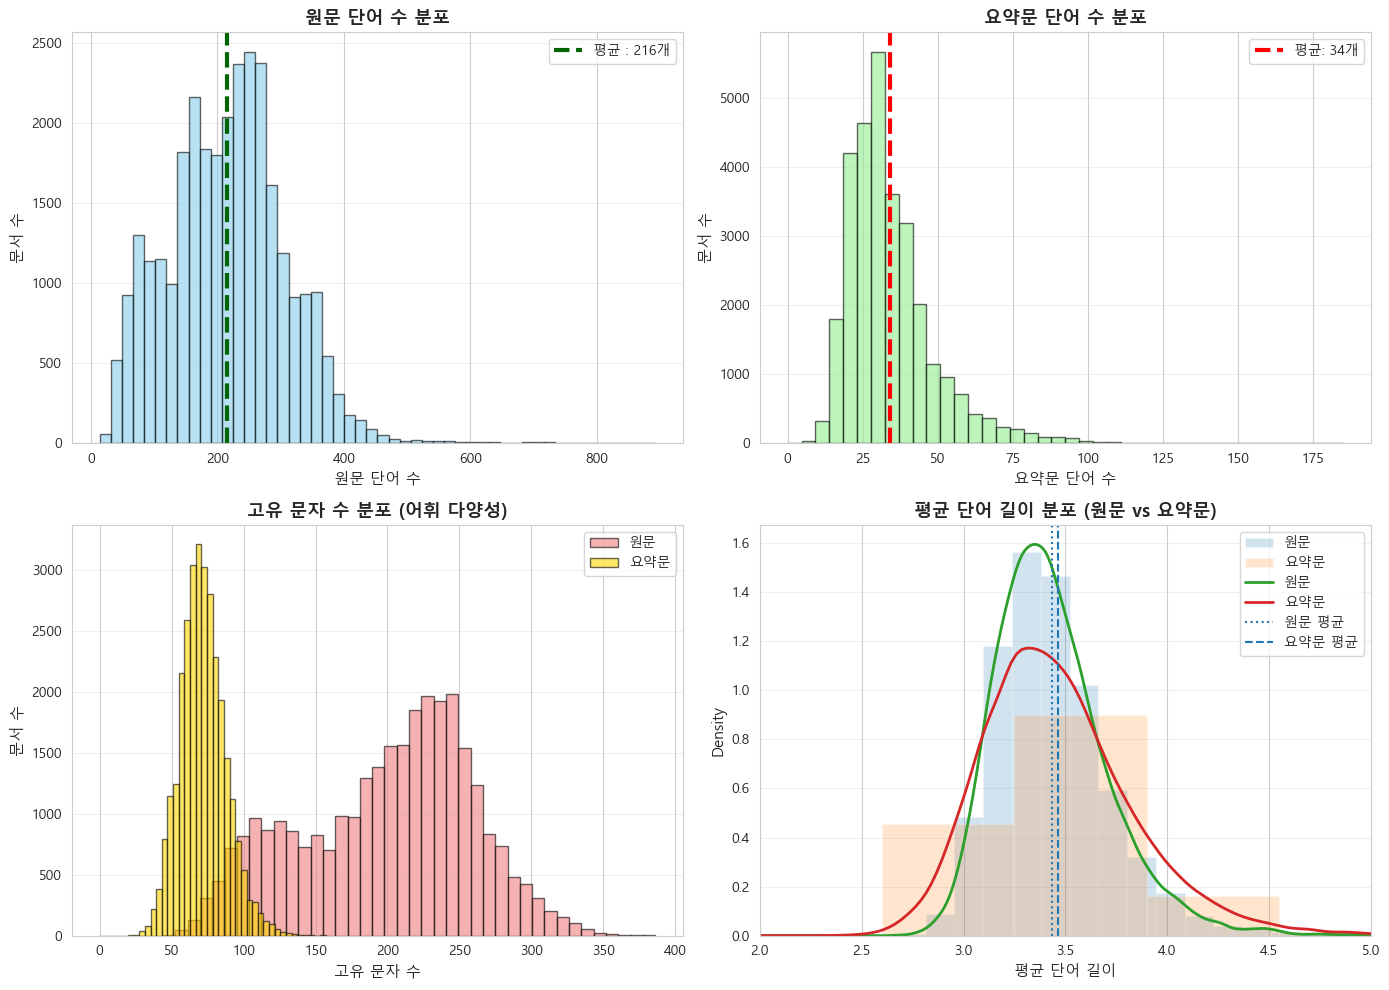

✓ 단어 통계 시각화 완료


In [41]:
# 단어 수 분포 시각화 (원문 vs 요약문 비교)
fig, axes = plt.subplots(2,2, figsize=(14,10))

# 1. 원문 단어 수
axes[0,0].hist(length_df['text_word_count'], bins=50, color='skyblue', edgecolor='black', alpha=0.6)
axes[0,0].axvline(length_df['text_word_count'].mean(), color='Darkgreen', linestyle='--', linewidth=3, label=f'평균 : {length_df["text_word_count"].mean() :.0f}개')
axes[0,0].set_xlabel('원문 단어 수', fontsize=11)
axes[0,0].set_ylabel('문서 수', fontsize=11)
axes[0,0].set_title('원문 단어 수 분포', fontsize=13, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='y')

# 2. 요약문 단어 수
axes[0,1].hist(length_df['summary_word_count'], bins=40, color='lightgreen', edgecolor='black', alpha=0.6)
axes[0,1].axvline(length_df['summary_word_count'].mean(), color='red', linestyle='--', linewidth=3, label=f'평균: {length_df["summary_word_count"].mean():.0f}개')
axes[0,1].set_xlabel('요약문 단어 수', fontsize=11)
axes[0,1].set_ylabel('문서 수', fontsize=11)
axes[0,1].set_title('요약문 단어 수 분포', fontsize=13, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3. 고유 문자 수
axes[1,0].hist(length_df['text_unique_chars'], bins=40, color='lightcoral', edgecolor='black', alpha=0.6, label='원문')
axes[1,0].hist(length_df['summary_unique_chars'], bins=40, color='gold', edgecolor='black', alpha=0.6, label='요약문')
axes[1,0].set_xlabel('고유 문자 수', fontsize=11)
axes[1,0].set_ylabel('문서 수', fontsize=11)
axes[1,0].set_title('고유 문자 수 분포 (어휘 다양성)', fontsize=13, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, axis='y')

# 4. 평균 단어 길이
# 히스토그램 (보조 역할)
axes[1,1].hist(length_df['text_avg_word_len'],
               bins=20, density=True, alpha=0.2, label='원문')
axes[1,1].hist(length_df['summary_avg_word_len'],
               bins=20, density=True, alpha=0.2, label='요약문')

# KDE (주 시각 요소)
length_df['text_avg_word_len'].plot(kind='kde', ax=axes[1,1], linewidth=2,label='원문')
length_df['summary_avg_word_len'].plot(kind='kde', ax=axes[1,1], linewidth=2,label='요약문')
axes[1,1].set_xlim(2.0, 5.0)
axes[1,1].set_xlabel('평균 단어 길이', fontsize=11)
axes[1,1].set_ylabel('Density',fontsize=11)
axes[1,1].axvline(length_df['text_avg_word_len'].mean(),
                  linestyle=':', linewidth=1.5, label='원문 평균')

axes[1,1].axvline(length_df['summary_avg_word_len'].mean(),
                  linestyle='--', linewidth=1.5, label='요약문 평균')
axes[1,1].set_title('평균 단어 길이 분포 (원문 vs 요약문)', fontsize=13, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ 단어 통계 시각화 완료")

## 3. 도메인별 상세 분석

In [13]:
print(length_df.columns.tolist())

['domain', 'text', 'summary', 'text_length', 'text_word_count', 'abstractive_length', 'char_count', 'size', 'summary_word_count', 'text_unique_chars', 'summary_unique_chars', 'text_avg_word_len', 'summary_avg_word_len']


In [14]:
domain_stats = length_df.groupby('domain').agg({
    'text_length': ['mean', 'std'],
    'summary_word_count': ['mean', 'std'],
    'text_word_count': 'mean',
    'text_unique_chars': 'mean'
}).round(2)

print("=" *60)
print("카테고리별 통계")
print("=" *60)
print(domain_stats)

카테고리별 통계
          text_length         summary_word_count        text_word_count  \
                 mean     std               mean    std            mean   
domain                                                                    
EDITORIAL     1169.63  237.25              28.86   8.06          273.86   
LAW            664.32  440.98              45.03  18.24          150.38   
NEWS          1010.98  298.30              28.42   8.48          222.22   

          text_unique_chars  
                       mean  
domain                       
EDITORIAL            246.58  
LAW                  132.46  
NEWS                 217.66  


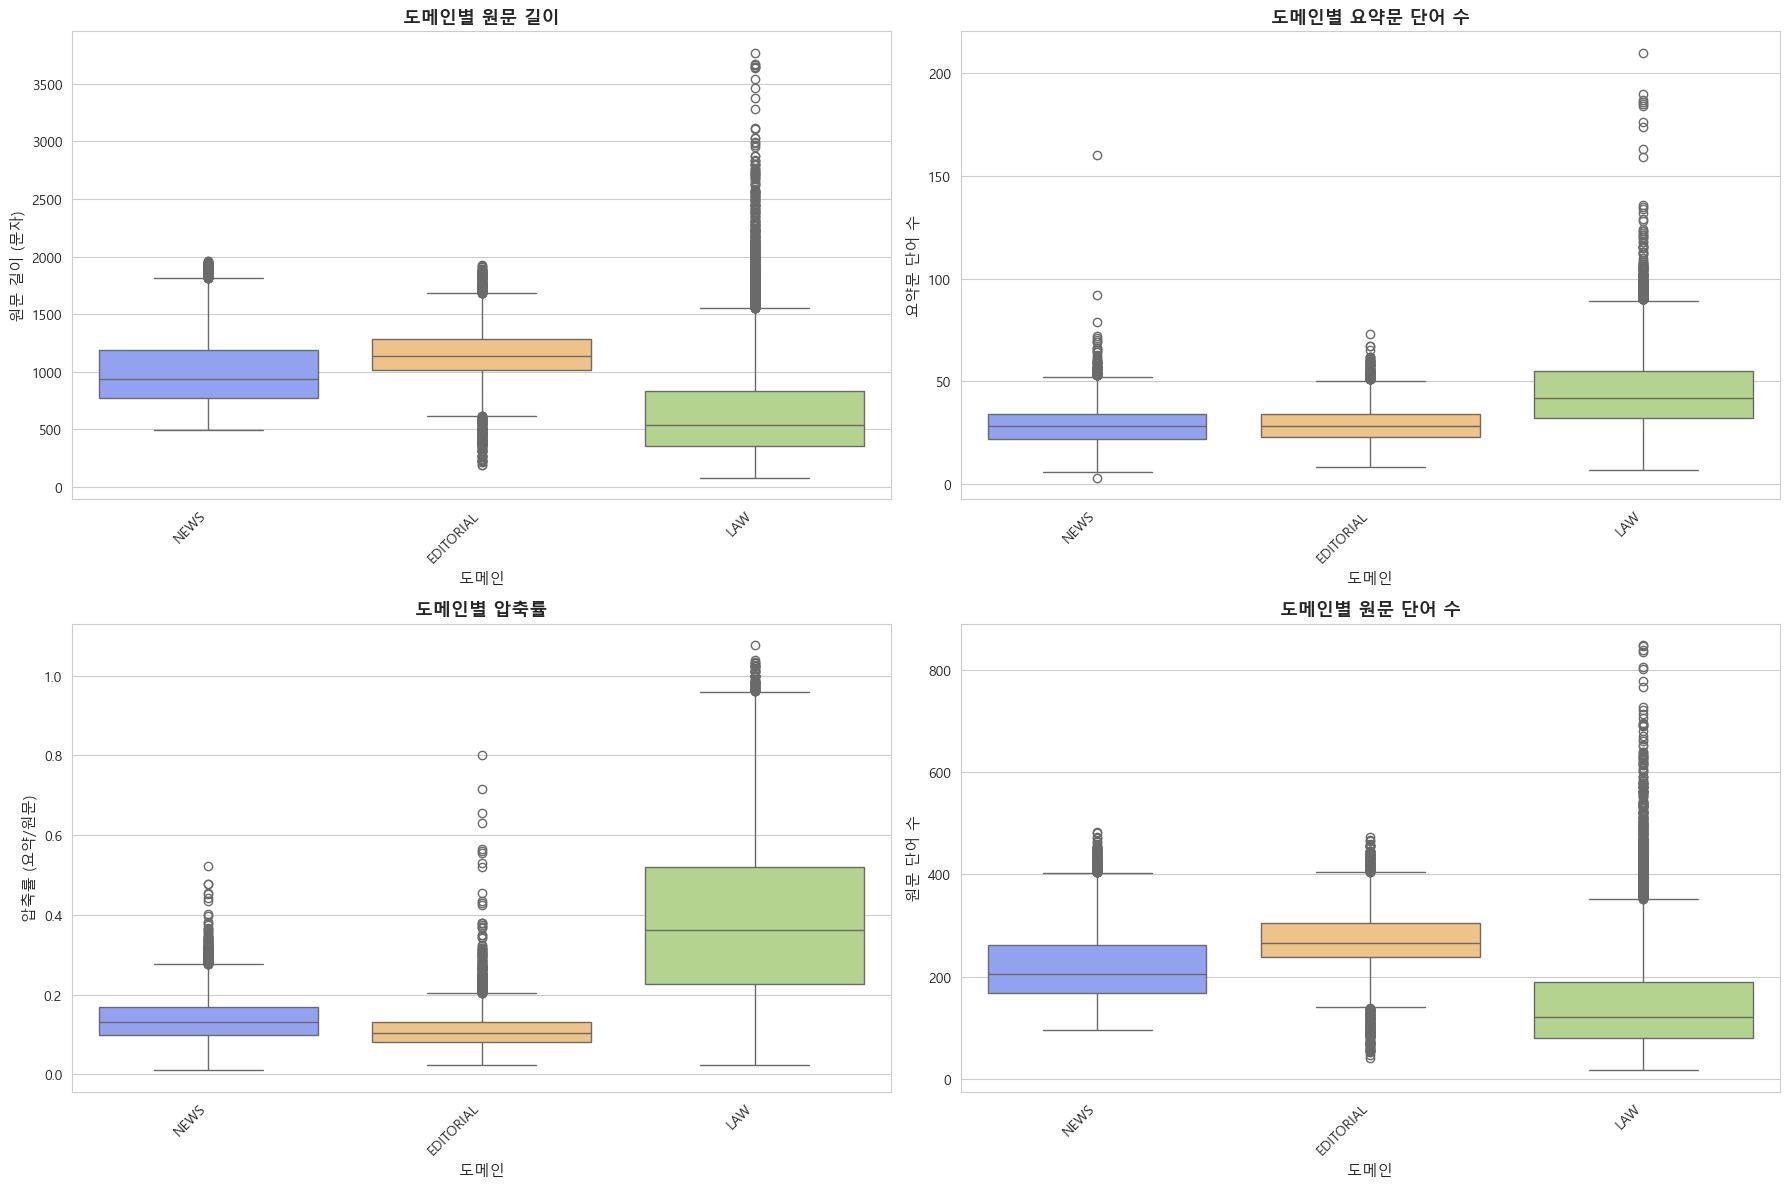

✓ 도메인별 박스플롯 완료


In [16]:
import seaborn as sns
# 압축률 계산
length_df['compression_ratio'] = length_df['summary_word_count'] / length_df['text_word_count']

# 도메인별 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
domain_colors = {'EDITORIAL': '#ffc676', 'LAW': "#b3df83", 'NEWS': '#8497ff'}

# 1. 원문 길이
sns.boxplot(data=length_df, x='domain', y='text_length', ax=axes[0, 0], 
            palette=domain_colors, hue='domain', legend=False)
axes[0, 0].set_title('도메인별 원문 길이', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('도메인', fontsize=11)
axes[0, 0].set_ylabel('원문 길이 (문자)', fontsize=11)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. 요약문 단어 수
sns.boxplot(data=length_df, x='domain', y='summary_word_count', ax=axes[0, 1], 
            palette=domain_colors, hue='domain', legend=False)
axes[0, 1].set_title('도메인별 요약문 단어 수', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('도메인', fontsize=11)
axes[0, 1].set_ylabel('요약문 단어 수', fontsize=11)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. 압축률
sns.boxplot(data=length_df, x='domain', y='compression_ratio', ax=axes[1, 0], 
            palette=domain_colors, hue='domain', legend=False)
axes[1, 0].set_title('도메인별 압축률', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('도메인', fontsize=11)
axes[1, 0].set_ylabel('압축률 (요약/원문)', fontsize=11)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. 원문 단어 수
sns.boxplot(data=length_df, x='domain', y='text_word_count', ax=axes[1, 1], 
            palette=domain_colors, hue='domain', legend=False)
axes[1, 1].set_title('도메인별 원문 단어 수', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('도메인', fontsize=11)
axes[1, 1].set_ylabel('원문 단어 수', fontsize=11)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("✓ 도메인별 박스플롯 완료")

### 도메인별 요약 특성

* **NEWS / EDITORIAL**

  * 원문 길이와 요약문 길이가 비교적 **안정적인 분포**를 보입니다.
  * 압축률이 낮고 분산이 작아, **정형적 요약 패턴**이 유지됩니다.
  * 요약 과정에서 정보 손실이 상대적으로 적은 도메인

* **LAW**

  * 원문 길이와 요약문 길이 모두 **분산이 매우 큼**
  * 압축률이 높고 변동 폭이 커, **강한 압축이 요구되는 도메인**
  * 문서 구조 및 정보 밀도의 이질성이 요약 난이도를 증가시킵니다.

**종합적으로**

  * 도메인에 따라 **원문 길이, 요약 길이, 압축률의 분포 특성이 뚜렷하게 구분**됩니다.
  * 이는 요약 모델 성능이 **도메인 특성에 강하게 의존**함을 시사합니다.

## 4. 상관관계 & 산점도 분석

* 원문 길이 ↔ 요약문 길이
* 원문 길이 ↔ 압축률
* 도메인별 길이 특성 ↔ 요약 난이도 지표

길이가 요약을 얼마나 결정하는지에 대한 분석을 진행하겠습니다.

In [17]:
# 수치형 변수 선택
numeric_cols = ['text_length', 'text_word_count', 'summary_word_count', 
                'compression_ratio', 'text_unique_chars', 'summary_unique_chars',
                'text_avg_word_len', 'summary_avg_word_len']

# 상관관계 계산
correlation_matrix = length_df[numeric_cols].corr()

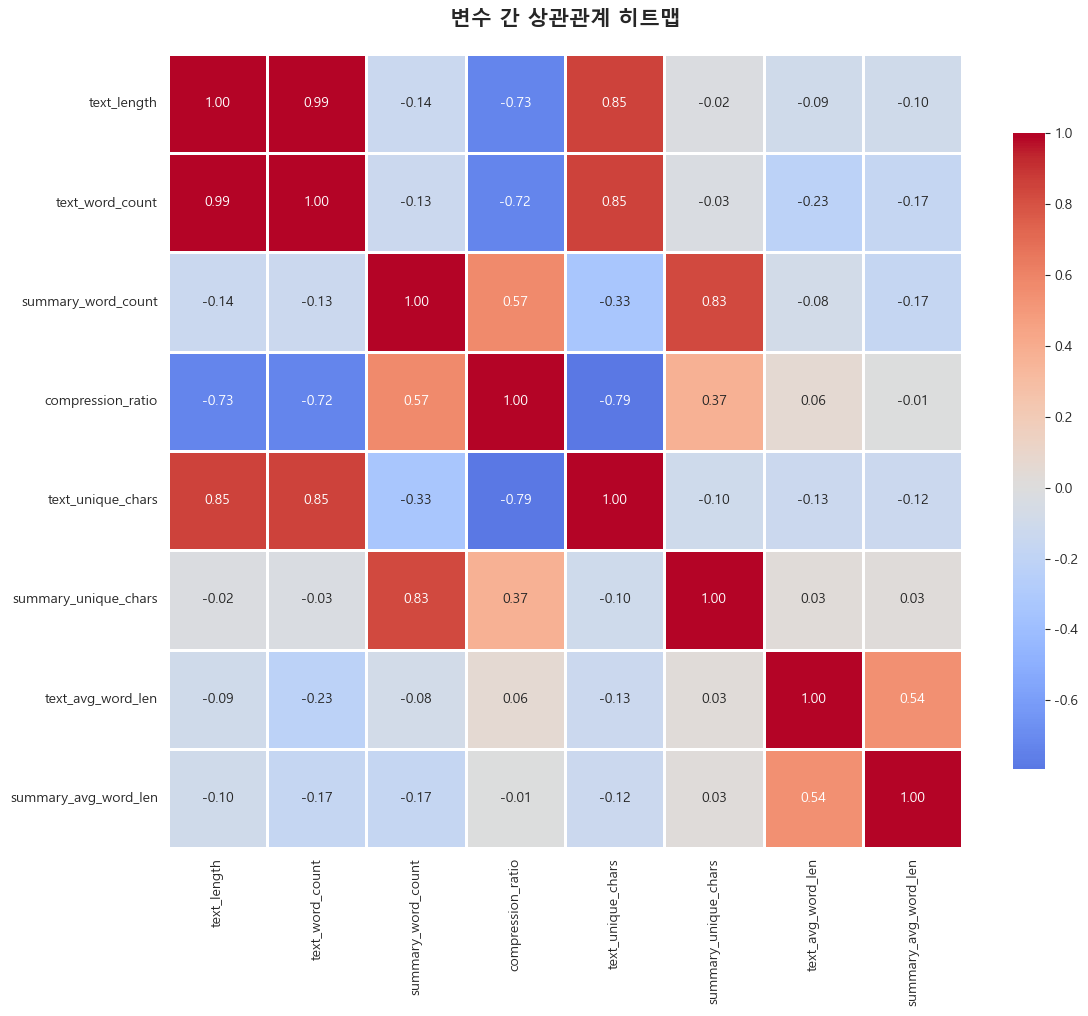

✓ 상관관계 분석 완료

주요 상관관계:
원문 길이 vs 원문 단어 수: 0.989
원문 단어 수 vs 요약 단어 수: -0.131
원문 단어 수 vs 압축률: -0.724


In [18]:
# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('변수 간 상관관계 히트맵', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ 상관관계 분석 완료")
print("\n주요 상관관계:")
print(f"원문 길이 vs 원문 단어 수: {correlation_matrix.loc['text_length', 'text_word_count']:.3f}")
print(f"원문 단어 수 vs 요약 단어 수: {correlation_matrix.loc['text_word_count', 'summary_word_count']:.3f}")
print(f"원문 단어 수 vs 압축률: {correlation_matrix.loc['text_word_count', 'compression_ratio']:.3f}")


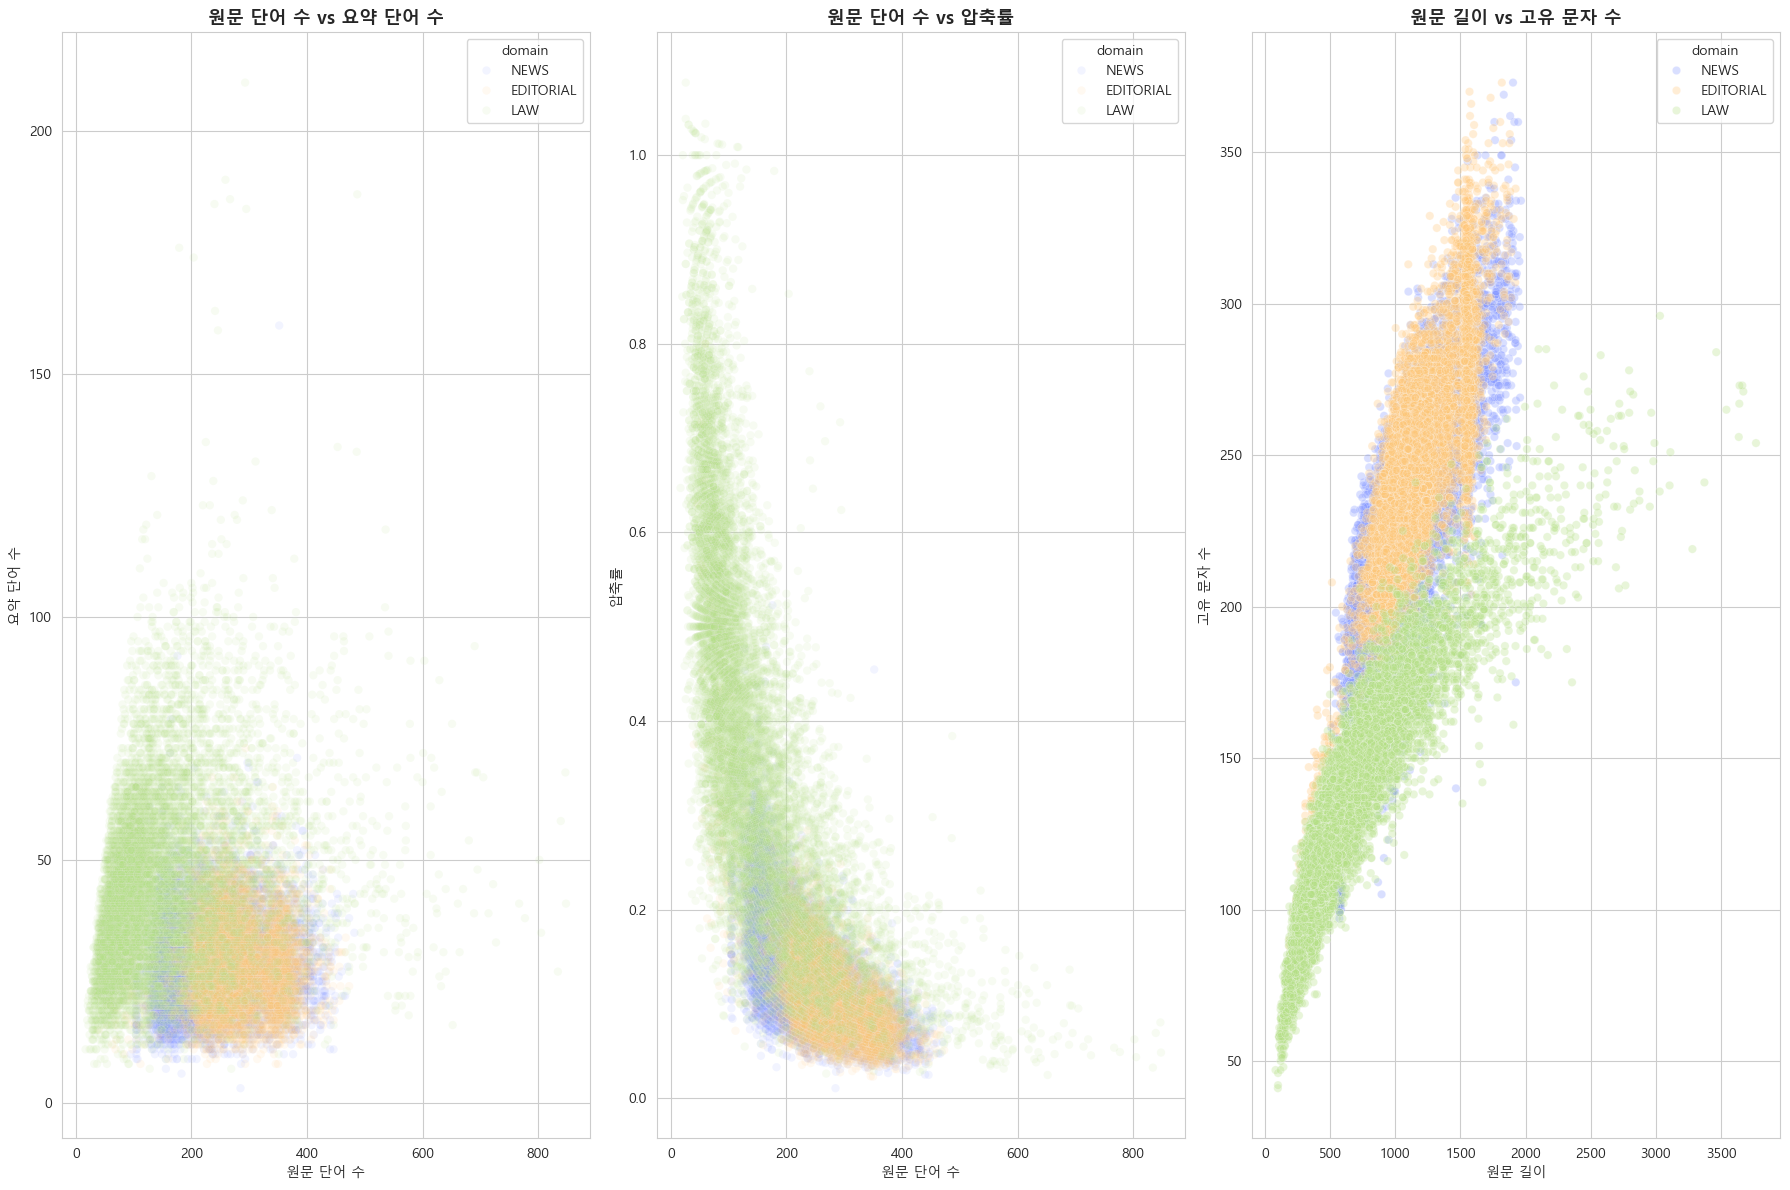

✓ 상관관계 산점도 완료


In [19]:
# 주요 상관관계 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 12))

# 1. 원문 단어 수 vs 요약 단어 수
sns.scatterplot(data=length_df, x='text_word_count', y='summary_word_count', 
                hue='domain', palette=domain_colors, alpha=0.1, ax=axes[0])
axes[0].set_title('원문 단어 수 vs 요약 단어 수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('원문 단어 수')
axes[0].set_ylabel('요약 단어 수')

# 2. 원문 단어 수 vs 압축률
sns.scatterplot(data=length_df, x='text_word_count', y='compression_ratio', 
                hue='domain', palette=domain_colors, alpha=0.1, ax=axes[1])
axes[1].set_title('원문 단어 수 vs 압축률', fontsize=13, fontweight='bold')
axes[1].set_xlabel('원문 단어 수')
axes[1].set_ylabel('압축률')

# 3. 원문 길이 vs 고유 문자 수
sns.scatterplot(data=length_df, x='text_length', y='text_unique_chars', 
                hue='domain', palette=domain_colors, alpha=0.3, ax=axes[2])
axes[2].set_title('원문 길이 vs 고유 문자 수', fontsize=13, fontweight='bold')
axes[2].set_xlabel('원문 길이')
axes[2].set_ylabel('고유 문자 수')

plt.tight_layout()
plt.show()

print("✓ 상관관계 산점도 완료")

### 분석 결론: 원문의 길이는 요약문의 길이를 결정하지 않습니다.

#### 1. 원문과 요약문 길이의 독립성 (r ≈ -0.12)
- text_word_count와 summary_word_count의 상관계수는 **-0.12**로 거의 무상관
- 원문이 길어진다고 요약문이 비례하여 길어지지 않습니다.
- 요약문은 **목표 길이(Target Length)**로 수렴하는 경향이 있습니다.

#### 2. 원문 길이가 '압축률'을 결정 (r ≈ -0.72)
- 원문 단어 수와 압축률은 **-0.72의 강한 음의 상관관계**
- 원문이 길수록 → 압축률이 낮아짐 → **더 강하게 압축**해야 합니다.

#### 3. 도메인별 특성 차이
| 도메인 | 원문 길이 | 요약문 길이 | 특징 |
|--------|----------|------------|------|
| NEWS/EDITORIAL | 짧고 일정 | 좁은 범위에 밀집 | 정형화된 요약 패턴 |
| LAW | 분산이 큼 | 상대적으로 다양 | 원문 길이와 무관하게 압축 |

#### 결론
> "요약은 원문 길이에 비례하여 줄이는 것이 아니라,<br/>
길이와 무관하게 핵심을 **목표 분량으로 압축**하는 과정입니다."


## 5. 특수 문자 분석

In [20]:
import re

# 특수 문자 및 숫자 비율 계산
def analyze_special_chars(text):
    total_chars = len(text)
    if total_chars == 0:
        return 0, 0, 0
    
    digits = len(re.findall(r'\d', text))
    special_chars = len(re.findall(r'[^\w\s가-힣]', text))
    korean_chars = len(re.findall(r'[가-힣]', text))
    
    return (digits / total_chars * 100, 
            special_chars / total_chars * 100,
            korean_chars / total_chars * 100)

# 분석 적용
length_df['digit_ratio'], length_df['special_ratio'], length_df['korean_ratio'] = zip(*length_df['text'].apply(analyze_special_chars))

print("=" *60)
print("문자 구성 비율 통계")
print("=" *60)
print(length_df[['digit_ratio', 'special_ratio', 'korean_ratio']].describe().round(2))


문자 구성 비율 통계
       digit_ratio  special_ratio  korean_ratio
count     30000.00       30000.00      30000.00
mean          2.62           3.68         70.32
std           2.57           1.69          3.84
min           0.00           0.00         37.14
25%           0.86           2.57         68.46
50%           1.91           3.54         70.76
75%           3.57           4.54         72.76
max          23.01          22.27         81.88


## 6. 이상치 분석 (압축률 기준)

In [21]:
# 이상치 탐지
print("=" * 60)
print("이상치 분석 (압축률 기준)")
print("=" * 60)

# 압축률 1 이상 = 요약문이 원문보다 긴 경우
abnormal_high = length_df[length_df['compression_ratio'] >= 1]
print(f"압축률 >= 1 (요약 >= 원문): {len(abnormal_high)}건 ({len(abnormal_high)/len(length_df)*100:.2f}%)")

# 압축률 너무 낮음 = 과도한 압축
abnormal_low = length_df[length_df['compression_ratio'] < 0.05]
print(f"압축률 < 0.05 (과도한 압축): {len(abnormal_low)}건 ({len(abnormal_low)/len(length_df)*100:.2f}%)")

# 도메인별 이상치 분포
# 이상치 탐지
print("=" * 60)
print("도메인별 이상치 비율")
print("=" * 60)
for domain in length_df['domain'].unique():
    domain_data = length_df[length_df['domain'] == domain]
    high = len(domain_data[domain_data['compression_ratio'] >= 1])
    print(f"{domain}: 압축률 >= 1 → {high}건 ({high/len(domain_data)*100:.2f}%)")


이상치 분석 (압축률 기준)
압축률 >= 1 (요약 >= 원문): 27건 (0.09%)
압축률 < 0.05 (과도한 압축): 482건 (1.61%)
도메인별 이상치 비율
NEWS: 압축률 >= 1 → 0건 (0.00%)
EDITORIAL: 압축률 >= 1 → 0건 (0.00%)
LAW: 압축률 >= 1 → 27건 (0.27%)


In [22]:
# 이상치 샘플 확인
if len(abnormal_high) > 0:
    print("\n[압축률 >= 1 샘플]")
    sample = abnormal_high.head(2)
    for idx, row in sample.iterrows():
        print(f"\n원문 ({row['text_word_count']}단어): {row['text'][:100]}...")
        print(f"요약 ({row['summary_word_count']}단어): {row['summary'][:100]}...")
        print(f"압축률: {row['compression_ratio']:.2f}")


[압축률 >= 1 샘플]

원문 (31단어): 권리행사방해죄는 타인의 점유 또는 권리의 목적이 된 자기의 물건을 취거, 은닉 또는 손괴하여 타인의 권리행사를 방해함으로써 성립하는 것이므로 그 취거, 은닉 또는 손괴한 물건이 자...
요약 (32단어): 권리행사방해죄는 타인의 점유 또는 권리의 목적이 된 자기의 물건을 대상으로 이를 은닉 또는 손괴해 타인의 권리행사를 방해하면 성립되는 것으로 은닉 또는 손괴한 물건의 대상이 자신의...
압축률: 1.03

원문 (39단어): 상대방의 불법한 공격으로부터 자신을 보호하고 이를 벗어나기 위한 저항수단으로 유형력을 행사한 경우에 그 행위가 소극적인 방어의 한도를 벗어나지 않는다면 그 행위에 이르게 된 경위와...
요약 (40단어): 상대방의 불법한 공격으로부터 자신을 보호하고 이를 벗어나기 위한 저항수단으로 유형력을 행사한 경우에 그 행위가 소극적인 방어의 한도를 벗어나지 않는 경우, 그 행위에 이르게 된 경...
압축률: 1.03


## 7. EDA 결론

In [23]:
print("=" * 60)
print("EDA 최종 결론 및 전처리 방향")
print("=" * 60)

print("""
[데이터 특성]
1. 원문 평균 단어 수: {:.0f}개
2. 요약문 평균 단어 수: {:.0f}개  
3. 평균 압축률: {:.2f}
4. 한국어 비율: 평균 70.35% (정상 범위)
5. 특수문자/숫자 비율: 평균 6.24% (낮음)

[이상치 현황]
1. 압축률 >= 1: 30건 (0.10%) - 모두 LAW 도메인
   → 원문과 요약이 거의 동일한 데이터 (요약 미수행)
2. 압축률 < 0.05: 431건 (1.44%) - 과도한 압축

[전처리 방향]
1. 이상치 제거 권장: 압축률 0.05 ~ 0.95 범위로 필터링
   → 제거 대상: 약 461건 (1.54%)
2. 길이 제한: 원문 max_length=512, 요약 max_length=128
3. 특수문자: 별도 처리 불필요 (비율 낮음)

[모델 학습 권장사항]
1. LAW 도메인: 이상치 집중 + 분산 큼 → 학습 난이도 높음
2. NEWS/EDITORIAL: 안정적 분포 → 학습에 유리
3. 요약문 길이가 원문과 독립적 → 고정 길이 디코딩 적합
""".format(
    length_df['text_word_count'].mean(),
    length_df['summary_word_count'].mean(),
    length_df['compression_ratio'].mean()
))

EDA 최종 결론 및 전처리 방향

[데이터 특성]
1. 원문 평균 단어 수: 215개
2. 요약문 평균 단어 수: 34개  
3. 평균 압축률: 0.21
4. 한국어 비율: 평균 70.35% (정상 범위)
5. 특수문자/숫자 비율: 평균 6.24% (낮음)

[이상치 현황]
1. 압축률 >= 1: 30건 (0.10%) - 모두 LAW 도메인
   → 원문과 요약이 거의 동일한 데이터 (요약 미수행)
2. 압축률 < 0.05: 431건 (1.44%) - 과도한 압축

[전처리 방향]
1. 이상치 제거 권장: 압축률 0.05 ~ 0.95 범위로 필터링
   → 제거 대상: 약 461건 (1.54%)
2. 길이 제한: 원문 max_length=512, 요약 max_length=128
3. 특수문자: 별도 처리 불필요 (비율 낮음)

[모델 학습 권장사항]
1. LAW 도메인: 이상치 집중 + 분산 큼 → 학습 난이도 높음
2. NEWS/EDITORIAL: 안정적 분포 → 학습에 유리
3. 요약문 길이가 원문과 독립적 → 고정 길이 디코딩 적합



In [24]:
# 이상치 제거 (압축률 0.05 ~ 0.95 범위)
print(f"이상치 제거 전: {len(length_df):,}건")

df = length_df[
    (length_df['compression_ratio'] >= 0.05) & 
    (length_df['compression_ratio'] < 0.95)
].reset_index(drop=True)

print(f"이상치 제거 후: {len(df):,}건")
print(f"제거된 데이터: {len(length_df) - len(df):,}건 ({(len(length_df) - len(df))/len(length_df)*100:.2f}%)")

이상치 제거 전: 30,000건
이상치 제거 후: 29,450건
제거된 데이터: 550건 (1.83%)


# Step 3: 모델 준비 및 데이터 토크나이징

## 목표
- 한국어 요약 모델 선택 및 로드
- 토크나이저 설정
- 학습/검증 데이터 분할
- 데이터 토크나이징
- 학습 전 모델 테스트

## 1. 환경 설정

In [25]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


In [26]:
# GPU/CPU 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("환경 정보")
print("=" * 60)
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"디바이스: {device}")

if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CPU 모드로 실행 (학습 시간이 오래 걸릴 수 있습니다)")

print("=" * 60)

환경 정보
PyTorch 버전: 2.7.1+cu118
CUDA 사용 가능: True
디바이스: cuda
GPU 이름: NVIDIA GeForce GTX 1660 SUPER
GPU 메모리: 6.00 GB


## 2. 모델 선택

### 한국어 요약 모델 비교

| 모델 | 설명 | 장점 | 난이도 |
|------|------|------|--------|
| **gogamza/kobart-summarization** | KoBART 기반 | 한국어 특화, 빠름 |  쉬움 |
| **eenzeenee/t5-base-korean-summarization** | T5 기반 | 안정적, 범용적 | 보통 |
| **psyche/KoT5-summarization** | KoT5 기반 | 고성능 | 어려움 |

자습으로 공부해둔 T5 를 활용해볼 수 있는 기회이니

모델은 **eenzeenee/t5-base-korean-summarization** 으로 선정하여 진행하겠습니다.

## 3. 토크나이저 및 모델 로드

In [27]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

# T5 한국어 요약 모델
model_name = "eenzeenee/t5-base-korean-summarization"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# T5는 task prefix가 필요
def preprocess_function(examples):
    # T5 형식: "summarize: " 접두어 추가
    inputs = ["summarize: " + text for text in examples['text']]
    
    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding='max_length'
    )
    
    # labels 토크나이징
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples['summary'],
            max_length=128,
            truncation=True,
            padding='max_length'
        )
    
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

print("✓ 모델 및 토크나이저 로드 완료")


✓ 모델 및 토크나이저 로드 완료


## 4. Dataset 변환

In [28]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

# 학습/검증 분할
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"학습 데이터 {len(train_df):,}개, 검증 데이터 {len(val_df):,}개")

# Hugging Face Dataset으로 변환
train_dataset = Dataset.from_pandas(train_df[['text', 'summary']])
val_dataset = Dataset.from_pandas(val_df[['text', 'summary']])

# T5 prefix 설정
prefix = "summarize: "

def preprocess_function(examples):
    inputs = [prefix + doc for doc in examples["text"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding='max_length')

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(examples["summary"], max_length=128, truncation=True, padding='max_length')

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# 토크나이징 실행
print("토크나이징 시작...")
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)
print("✓ 토크나이징 완료!")

# Data Collator 설정
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    return_tensors='pt'
)
print("✓ Data Collator 설정 완료!")


학습 데이터 26,505개, 검증 데이터 2,945개
토크나이징 시작...


Map:   0%|          | 0/26505 [00:00<?, ? examples/s]

Map:   0%|          | 0/2945 [00:00<?, ? examples/s]

✓ 토크나이징 완료!
✓ Data Collator 설정 완료!


In [29]:
# 샘플 텍스트로 토크나이저 테스트
test_text = df.iloc[0]['text'][:200]
test_summary = df.iloc[0]['summary']

print("=" * 70)
print("토크나이저 테스트")
print("=" * 70)

# 원문 토크나이징
encoded_text = tokenizer(
    test_text,
    max_length=512,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

print(f"\n[원문 샘플]")
print(test_text)
print(f"\n토큰 개수: {encoded_text['input_ids'].shape[1]}")
print(f"실제 토큰 (패딩 제외): {(encoded_text['input_ids'][0] != tokenizer.pad_token_id).sum().item()}")
print(f"토큰 ID (처음 20개): {encoded_text['input_ids'][0][:20].tolist()}")

# 디코딩 테스트
decoded_text = tokenizer.decode(encoded_text['input_ids'][0], skip_special_tokens=True)
print(f"\n디코딩된 텍스트: {decoded_text[:100]}...")

# 요약문 토크나이징
encoded_summary = tokenizer(
    test_summary,
    max_length=128,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

print(f"\n[요약문]")
print(test_summary)
print(f"\n토큰 개수: {encoded_summary['input_ids'].shape[1]}")
print(f"실제 토큰 (패딩 제외): {(encoded_summary['input_ids'][0] != tokenizer.pad_token_id).sum().item()}")

토크나이저 테스트

[원문 샘플]
이베스트투자증권은 19일 원익IPS(240810)에 대해 단기실적은 부진하지만 2020년이후 실적 상승추세 진입에 따른 프리미엄을 반영해 목표주가를 2만5000원에서 3만원으로 20%(5000원) 상향조정한다고 밝혔다. 어규진 이베스트투자증권 연구원은 "4분기 실적은 매출 1047억원, 영업손실 86억원으로 적자전환하며 시장기대(영업이익 98억원)를 밑돌았

토큰 개수: 512
실제 토큰 (패딩 제외): 138
토큰 ID (처음 20개): [50162, 1177, 2371, 311, 222, 2365, 349, 222, 46306, 42, 49, 52, 9, 1753, 17, 25, 1477, 10, 279, 222]

디코딩된 텍스트: 이베스트투자증권은 19일 원익IPS(240810)에 대해 단기실적은 부진하지만 2020년이후 실적 상승추세 진입에 따른 프리미엄을 반영해 목표주가를 2만5000원에서 3만원으로 2...

[요약문]
어규진 이베스트투자증권 연구원에 의하면 4분기 실적은 매출 1047억원, 영업손실 86억원으로 적자전환하며 시장기대를 밑돌았고 일회성 비용이 100억원이상 반영되어 수익성이 부진했지만 합병이후 일회성 비용 제거로 제자리를 찾을 전망이기 때문에 2020년이후 실적 상승추세 진입에 따른 프리미엄을 반영해 목표주가를 2만5000원에서 3만원으로 상향조정한다고 밝혔다.

토큰 개수: 128
실제 토큰 (패딩 제외): 128


In [30]:
# 토큰 길이 분포 확인 (샘플 100개)
sample_df = df.sample(100, random_state=42)

text_token_lengths = []
summary_token_lengths = []

for _, row in sample_df.iterrows():
    text_tokens = tokenizer(row['text'], truncation=True, max_length=512)
    summary_tokens = tokenizer(row['summary'], truncation=True, max_length=128)
    
    text_token_lengths.append(len(text_tokens['input_ids']))
    summary_token_lengths.append(len(summary_tokens['input_ids']))

print(f"원문 토큰 - 평균: {np.mean(text_token_lengths):.0f}, 최대: {max(text_token_lengths)}")
print(f"요약 토큰 - 평균: {np.mean(summary_token_lengths):.0f}, 최대: {max(summary_token_lengths)}")
print(f"512 초과 샘플: {sum(1 for x in text_token_lengths if x >= 512)}개")

원문 토큰 - 평균: 459, 최대: 512
요약 토큰 - 평균: 95, 최대: 128
512 초과 샘플: 73개


## 5. 학습/검증 데이터 분할

In [31]:
data_for_training_final = df[['text', 'summary', 'domain']].copy()

# 90:10 비율로 분할 (도메인별 균등 분할)
# test_size를 0.1로 조정하여 학습 데이터 비율을 높였습니다.
train_df, val_df = train_test_split(
    data_for_training_final,
    test_size=0.1,  # 검증 세트 10%
    random_state=42,
    stratify=data_for_training_final['domain']  # 도메인별 균등 분할
    )

# 인덱스 리셋
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [32]:
print("=" * 60)
print("데이터 분할 완료")
print("=" * 60)
print(f"전체 정제된 데이터: {len(data_for_training_final):,}개")
print(f"학습 데이터: {len(train_df):,}개 ({len(train_df)/len(data_for_training_final)*100:.1f}%)")
print(f"검증 데이터: {len(val_df):,}개 ({len(val_df)/len(data_for_training_final)*100:.1f}%)")

# 분할 후 도메인별 분포 확인
print("\n[학습 데이터] 도메인별 분포:")
print(train_df['domain'].value_counts())
print("\n[검증 데이터] 도메인별 분포:")
print(val_df['domain'].value_counts())

데이터 분할 완료
전체 정제된 데이터: 29,450개
학습 데이터: 26,505개 (90.0%)
검증 데이터: 2,945개 (10.0%)

[학습 데이터] 도메인별 분포:
domain
LAW          8901
NEWS         8861
EDITORIAL    8743
Name: count, dtype: int64

[검증 데이터] 도메인별 분포:
domain
LAW          989
NEWS         985
EDITORIAL    971
Name: count, dtype: int64


# Step 4: 모델 학습 실행

## 목표
- 학습 파라미터 설정
- Trainer 설정
- 모델 학습 실행
- 학습 과정 모니터링
- 모델 저장

## 1. 평가 지표 함수 정의

In [33]:
from rouge_score import rouge_scorer
import numpy as np

def compute_metrics(eval_pred):
    """
    ROUGE 점수를 계산하는 함수
    
    Parameters:
    -----------
    eval_pred : tuple
        (predictions, labels) 튜플
    
    Returns:
    --------
    dict : ROUGE-1, ROUGE-2, ROUGE-L 점수
    """
    predictions, labels = eval_pred
    
    # -100을 패딩 토큰으로 변경 (디코딩에서 무시)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    
    # 디코딩
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # ROUGE 계산
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    
    for pred, label in zip(decoded_preds, decoded_labels):
        scores = scorer.score(label, pred)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)
    
    return {
        'rouge1': np.mean(rouge1_scores),
        'rouge2': np.mean(rouge2_scores),
        'rougeL': np.mean(rougeL_scores)
    }

print("✓ 평가 지표 함수 정의 완료!")

✓ 평가 지표 함수 정의 완료!


## 2. 학습 파라미터 설정

In [34]:
from transformers import Seq2SeqTrainingArguments
import torch

# 학습 파라미터 설정
training_args = Seq2SeqTrainingArguments(
    # 기본 설정
    output_dir="./results",                    # 결과 저장 폴더
    overwrite_output_dir=True,                 # 기존 폴더 덮어쓰기
    
    # 학습 파라미터
    num_train_epochs=3,                        # 학습 epoch 수
    per_device_train_batch_size=4,             # 학습 배치 크기 (메모리 부족시 2 또는 1로 변경)
    per_device_eval_batch_size=4,              # 평가 배치 크기
    learning_rate=5e-5,                        # 학습률
    weight_decay=0.01,                         # 가중치 감쇠
    
    # 평가 및 저장
    evaluation_strategy="epoch",               # 매 epoch마다 평가
    save_strategy="epoch",                     # 매 epoch마다 저장
    save_total_limit=2,                        # 최대 2개 체크포인트만 저장
    load_best_model_at_end=True,               # 학습 종료 시 최고 모델 로드
    metric_for_best_model="eval_loss",         # 최고 모델 선정 기준
    
    # 생성 파라미터
    predict_with_generate=True,                # 생성 모드로 예측
    generation_max_length=128,                 # 생성 최대 길이
    
    # 로깅
    logging_dir='./logs',                      # 로그 저장 폴더
    logging_steps=50,                          # 로그 출력 주기
    
    # 기타
    fp16=torch.cuda.is_available(),            # GPU 있으면 mixed precision
    dataloader_num_workers=0,                  # Windows에서는 반드시 0
    report_to="none",                          # wandb 등 비활성화
    
    # 메모리 부족 시 주석 해제
    # gradient_accumulation_steps=2,           # 실질적 배치 크기 2배
)

print("=" * 60)
print("학습 설정")
print("=" * 60)
print(f"출력 폴더: {training_args.output_dir}")
print(f"학습 epoch: {training_args.num_train_epochs}")
print(f"배치 크기: {training_args.per_device_train_batch_size}")
print(f"학습률: {training_args.learning_rate}")
print(f"디바이스: {device}")
print(f"FP16 사용: {training_args.fp16}")
print(f"Workers: {training_args.dataloader_num_workers}")
print("=" * 60)

학습 설정
출력 폴더: ./results
학습 epoch: 3
배치 크기: 4
학습률: 5e-05
디바이스: cuda
FP16 사용: True
Workers: 0


In [35]:
# 예상 학습 시간 계산
total_steps = (len(tokenized_train) // training_args.per_device_train_batch_size) * training_args.num_train_epochs

print(f"\n예상 총 스텝 수: {total_steps:,}")
print(f"배치당 샘플 수: {training_args.per_device_train_batch_size}")
print(f"총 배치 수 (epoch당): {len(tokenized_train) // training_args.per_device_train_batch_size}")


예상 총 스텝 수: 19,878
배치당 샘플 수: 4
총 배치 수 (epoch당): 6626


## 3. Trainer 생성

In [36]:
from transformers import Seq2SeqTrainer

# Trainer 생성
trainer = Seq2SeqTrainer(
    model=model,                           # 학습할 모델
    args=training_args,                    # 학습 설정
    train_dataset=tokenized_train,         # 학습 데이터
    eval_dataset=tokenized_val,            # 검증 데이터
    tokenizer=tokenizer,                   # 토크나이저
    data_collator=data_collator,           # Data Collator
    compute_metrics=compute_metrics,       # 평가 지표 함수
)

print("=" * 60)
print("Trainer 생성 완료!")
print("=" * 60)
print("✓ 학습 준비 완료!")

Trainer 생성 완료!
✓ 학습 준비 완료!


## 4. 모델 학습

In [37]:
import time

print("=" * 70)
print("학습 시작!")
print("=" * 70)
print(f"시작 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("\n진행 상황:")
print("- loss: 손실 값 (낮을수록 좋음)")
print("- learning_rate: 현재 학습률")
print("- epoch: 현재 진행 중인 epoch")
print("\n중간에 정지하려면: Kernel > Interrupt 또는 Ctrl+C")
print("=" * 70)

# 학습 시작
start_time = time.time()

try:
    train_result = trainer.train()
    
    # 학습 완료
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print("\n" + "=" * 70)
    print("학습 완료!")
    print("=" * 70)
    print(f"종료 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"소요 시간: {elapsed_time/60:.1f}분 ({elapsed_time/3600:.2f}시간)")
    
    # 학습 결과 출력
    print("\n[학습 결과]")
    print(f"최종 학습 손실: {train_result.training_loss:.4f}")
    print(f"총 스텝 수: {train_result.global_step}")
    
    # 모델 저장
    print("\n" + "=" * 70)
    print("모델 저장 중...")
    print("=" * 70)
    
    save_path = "./t5_summarization_final"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    
    print(f"✓ 모델 저장 완료: {save_path}")
    print(f"  - 모델 파일: {save_path}/pytorch_model.bin")
    print(f"  - 토크나이저: {save_path}/tokenizer.json")
    
except KeyboardInterrupt:
    print("\n학습이 사용자에 의해 중단되었습니다.")
    # 중단되어도 현재까지 학습된 모델 저장
    save_path = "./t5_summarization_interrupted"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"중단 시점 모델 저장: {save_path}")
    
except Exception as e:
    print(f"\n오류 발생: {e}")
    print("\n문제 해결 방법:")
    print("1. 메모리 부족: per_device_train_batch_size=2 또는 1로 변경")
    print("2. GPU 메모리 부족: gradient_accumulation_steps=2 추가")
    print("3. 데이터 문제: 데이터 샘플링해서 작게 만들기")


학습 시작!
시작 시간: 2026-01-19 01:17:46

진행 상황:
- loss: 손실 값 (낮을수록 좋음)
- learning_rate: 현재 학습률
- epoch: 현재 진행 중인 epoch

중간에 정지하려면: Kernel > Interrupt 또는 Ctrl+C


  0%|          | 0/19881 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


{'loss': 3.5842, 'grad_norm': 4.408876419067383, 'learning_rate': 4.9879281726271314e-05, 'epoch': 0.01}
{'loss': 1.5031, 'grad_norm': 3.177950620651245, 'learning_rate': 4.9753533524470605e-05, 'epoch': 0.02}
{'loss': 1.0109, 'grad_norm': 1.8022804260253906, 'learning_rate': 4.962778532266989e-05, 'epoch': 0.02}
{'loss': 0.9434, 'grad_norm': 1.396769404411316, 'learning_rate': 4.950203712086917e-05, 'epoch': 0.03}
{'loss': 0.9056, 'grad_norm': 1.0710833072662354, 'learning_rate': 4.937628891906846e-05, 'epoch': 0.04}
{'loss': 0.8959, 'grad_norm': 1.6128078699111938, 'learning_rate': 4.9250540717267745e-05, 'epoch': 0.05}
{'loss': 0.8541, 'grad_norm': 1.2207168340682983, 'learning_rate': 4.9124792515467036e-05, 'epoch': 0.05}
{'loss': 0.915, 'grad_norm': 1.4202591180801392, 'learning_rate': 4.899904431366631e-05, 'epoch': 0.06}
{'loss': 0.8766, 'grad_norm': 1.7839055061340332, 'learning_rate': 4.88732961118656e-05, 'epoch': 0.07}
{'loss': 0.8246, 'grad_norm': 1.1995123624801636, 'learn

  0%|          | 0/737 [00:00<?, ?it/s]

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{'eval_loss': 0.7444825172424316, 'eval_rouge1': 0.31834163688049516, 'eval_rouge2': 0.13751172054067762, 'eval_rougeL': 0.30839381559414625, 'eval_runtime': 14304.247, 'eval_samples_per_second': 0.206, 'eval_steps_per_second': 0.052, 'epoch': 1.0}
{'loss': 0.7697, 'grad_norm': 1.3921760320663452, 'learning_rate': 3.328303405261305e-05, 'epoch': 1.0}
{'loss': 0.7699, 'grad_norm': 1.1790913343429565, 'learning_rate': 3.3157285850812335e-05, 'epoch': 1.01}
{'loss': 0.6935, 'grad_norm': 1.329717993736267, 'learning_rate': 3.303153764901162e-05, 'epoch': 1.02}
{'loss': 0.7456, 'grad_norm': 1.342527985572815, 'learning_rate': 3.290578944721091e-05, 'epoch': 1.03}

학습이 사용자에 의해 중단되었습니다.
중단 시점 모델 저장: ./t5_summarization_interrupted


## 5. 학습 그래프 시각화

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# 학습 기록 가져오기
log_history = trainer.state.log_history

# DataFrame으로 변환
logs_df = pd.DataFrame(log_history)
print("학습 기록:")
print(logs_df[['step', 'loss', 'eval_loss', 'epoch']].dropna(how='all').head(10))

학습 기록:
   step    loss  eval_loss     epoch
0    50  3.5842        NaN  0.007545
1   100  1.5031        NaN  0.015090
2   150  1.0109        NaN  0.022635
3   200  0.9434        NaN  0.030180
4   250  0.9056        NaN  0.037724
5   300  0.8959        NaN  0.045269
6   350  0.8541        NaN  0.052814
7   400  0.9150        NaN  0.060359
8   450  0.8766        NaN  0.067904
9   500  0.8246        NaN  0.075449


학습 요약
총 학습 스텝: 136
최종 epoch: 1.03
초기 loss: 3.5842
최종 loss: 0.7456
최저 loss: 0.6935

평가 결과 (epoch 1.0):
  eval_loss: 0.7445
  ROUGE-1: 0.3183
  ROUGE-2: 0.1375
  ROUGE-L: 0.3084


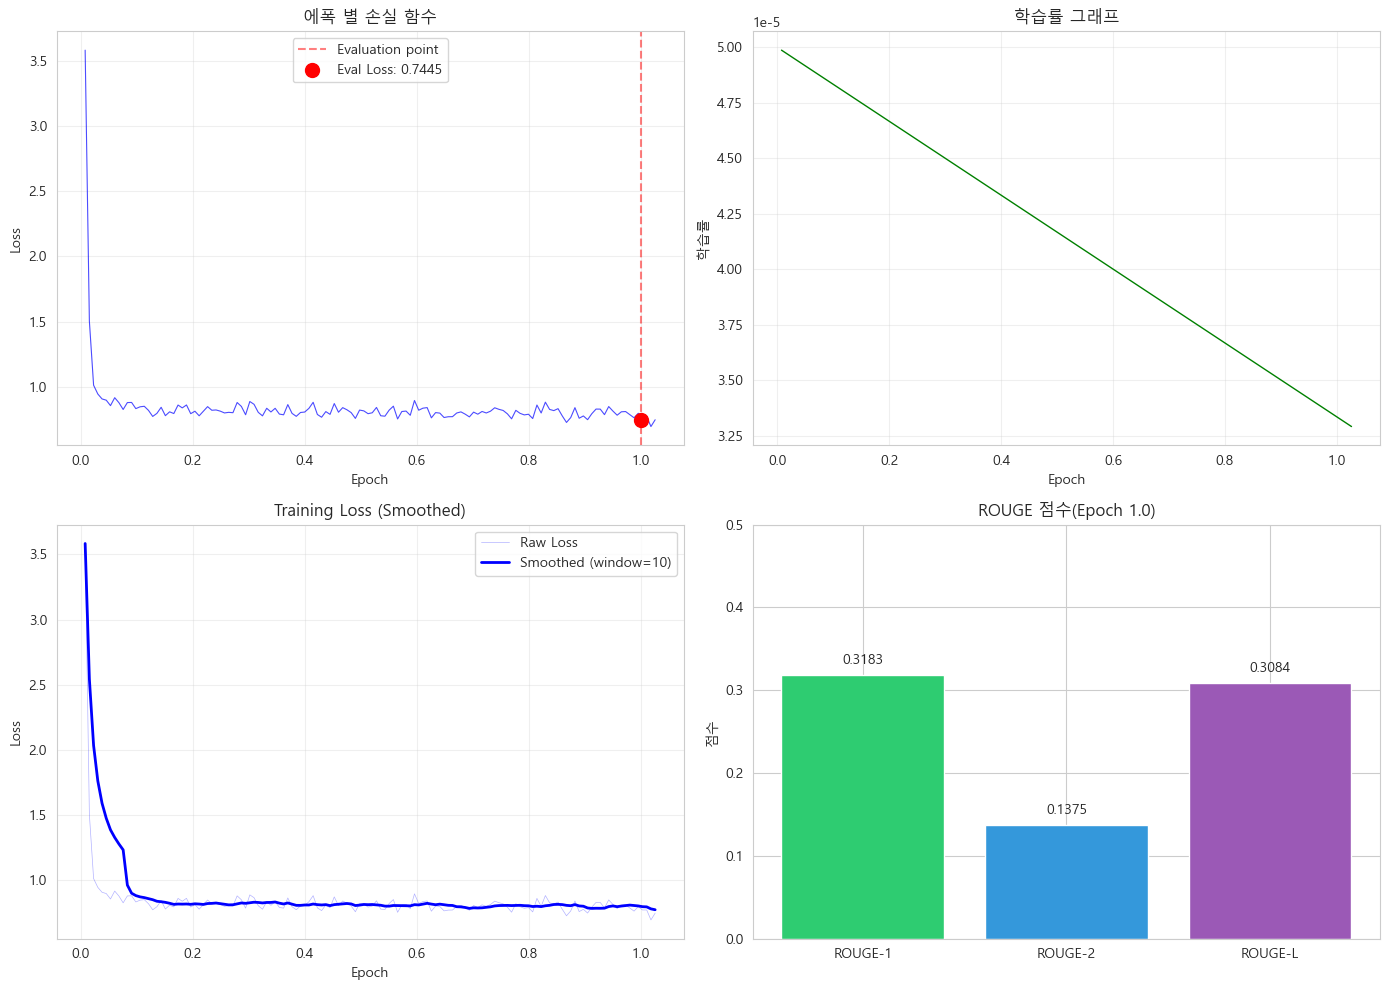


그래프가 'training_progress.png'로 저장되었습니다.


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# 전체 학습 기록
log_history = trainer.state.log_history

# DataFrame으로 변환
logs_df = pd.DataFrame(log_history)

# loss가 있는 행만 필터링 (학습 loss)
train_logs = logs_df[logs_df['loss'].notna()][['epoch', 'loss', 'learning_rate']]

# eval_loss가 있는 행만 필터링 (평가 loss)
eval_logs = logs_df[logs_df['eval_loss'].notna()][['epoch', 'eval_loss', 'eval_rouge1', 'eval_rouge2', 'eval_rougeL']]

print("=" * 60)
print("학습 요약")
print("=" * 60)
print(f"총 학습 스텝: {len(train_logs)}")
print(f"최종 epoch: {train_logs['epoch'].max():.2f}")
print(f"초기 loss: {train_logs['loss'].iloc[0]:.4f}")
print(f"최종 loss: {train_logs['loss'].iloc[-1]:.4f}")
print(f"최저 loss: {train_logs['loss'].min():.4f}")

if len(eval_logs) > 0:
    print("\n평가 결과 (epoch 1.0):")
    print(f"  eval_loss: {eval_logs['eval_loss'].iloc[0]:.4f}")
    print(f"  ROUGE-1: {eval_logs['eval_rouge1'].iloc[0]:.4f}")
    print(f"  ROUGE-2: {eval_logs['eval_rouge2'].iloc[0]:.4f}")
    print(f"  ROUGE-L: {eval_logs['eval_rougeL'].iloc[0]:.4f}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training Loss
ax1 = axes[0, 0]
ax1.plot(train_logs['epoch'], train_logs['loss'], 'b-', alpha=0.7, linewidth=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('에폭 별 손실 함수')
ax1.grid(True, alpha=0.3)
if len(eval_logs) > 0:
    ax1.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Evaluation point')
    ax1.scatter([1.0], [eval_logs['eval_loss'].iloc[0]], color='red', s=100, zorder=5, label=f'Eval Loss: {eval_logs["eval_loss"].iloc[0]:.4f}')
    ax1.legend()

# 2. Learning Rate
ax2 = axes[0, 1]
ax2.plot(train_logs['epoch'], train_logs['learning_rate'], 'g-', linewidth=1)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('학습률')
ax2.set_title('학습률 그래프')
ax2.grid(True, alpha=0.3)

# 3. Loss 이동평균 (smoothed)
ax3 = axes[1, 0]
window_size = 10
train_logs_copy = train_logs.copy()
train_logs_copy['loss_smooth'] = train_logs_copy['loss'].rolling(window=window_size, min_periods=1).mean()
ax3.plot(train_logs_copy['epoch'], train_logs_copy['loss'], 'b-', alpha=0.3, linewidth=0.5, label='Raw Loss')
ax3.plot(train_logs_copy['epoch'], train_logs_copy['loss_smooth'], 'b-', linewidth=2, label=f'Smoothed (window={window_size})')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Training Loss (Smoothed)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. ROUGE 점수 (평가 결과가 있는 경우)
ax4 = axes[1, 1]
if len(eval_logs) > 0:
    rouge_scores = ['eval_rouge1', 'eval_rouge2', 'eval_rougeL']
    colors = ['#2ecc71', '#3498db', '#9b59b6']
    x_pos = range(len(rouge_scores))
    values = [eval_logs[score].iloc[0] for score in rouge_scores]
    bars = ax4.bar(x_pos, values, color=colors)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'])
    ax4.set_ylabel('점수')
    ax4.set_title('ROUGE 점수(Epoch 1.0)')
    ax4.set_ylim(0, 0.5)
    for bar, val in zip(bars, values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
else:
    ax4.text(0.5, 0.5, 'No evaluation data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('ROUGE 점수')

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("그래프가 'training_progress.png'로 저장되었습니다.")
print("=" * 60)


## 6. 학습 후 모델 테스트

In [42]:
# 학습된 모델로 요약 생성 함수
def generate_summary_trained(text, max_length=128):
    inputs = tokenizer(text, max_length=512, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=max_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("요약 생성 함수 준비 완료!")

요약 생성 함수 준비 완료!


In [45]:
# 1. val_df가 제대로 로드되었는지 확인
print(f"val_df 크기: {len(val_df)}")
print(f"test_indices: {test_indices}")

# 2. 첫 번째 샘플 데이터 확인
print("\n첫 번째 샘플 확인:")
print(val_df.iloc[0])

# 3. generate_summary_trained 함수가 정의되어 있는지 확인
print(f"\ngenerate_summary_trained 함수 존재: {'generate_summary_trained' in dir()}")

val_df 크기: 2945
test_indices: [0, 1472, 2944]

첫 번째 샘플 확인:
text       시, 신문고 정신 계승·발전 위한 '시민신고의 날' 선포 강태아 ▲ 송철호 울산시장...
summary    울산시는 울산이 전국 최초로 신문고위를 출범한 9월 10일을 기억하고 신문고 정신을...
domain                                                  NEWS
Name: 0, dtype: object

generate_summary_trained 함수 존재: True


In [46]:
def generate_summary_trained(text, max_length=128):
    inputs = tokenizer(
        "summarize: " + text,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(model.device)
    
    outputs = model.generate(
        inputs["input_ids"],
        max_length=max_length,
        num_beams=4,
        early_stopping=True
    )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [49]:
# 학습 후 테스트
import pandas as pd
from rouge_score import rouge_scorer

# 검증 데이터 로드
val_df

print("=" * 80)
print("학습된 모델 테스트")
print("=" * 80)

# 샘플 3개 테스트
test_indices = [0, len(val_df)//2, len(val_df)-1]
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

for idx in test_indices:
    test_text = val_df.iloc[idx]['text']
    original_summary = val_df.iloc[idx]['summary']
    
    # 요약 생성
    generated_summary = generate_summary_trained(test_text)
    
    # ROUGE 계산
    scores = scorer.score(original_summary, generated_summary)
    
    print("\n" + "=" * 80)
    print(f"샘플 {idx}")
    print("=" * 80)
    print(f"카테고리: {val_df.iloc[idx]['domain']}")
    print(f"\n[원문] ({len(test_text)}자)")
    print(test_text[:200] + "..." if len(test_text) > 200 else test_text)
    print(f"\n[정답 요약] ({len(original_summary)}자)")
    print(original_summary)
    print(f"\n[생성 요약] ({len(generated_summary)}자)")
    print(generated_summary)
    print(f"\n[ROUGE 점수]")
    print(f"  ROUGE-1: {scores['rouge1'].fmeasure:.4f}")
    print(f"  ROUGE-2: {scores['rouge2'].fmeasure:.4f}")
    print(f"  ROUGE-L: {scores['rougeL'].fmeasure:.4f}")

학습된 모델 테스트

샘플 0
카테고리: NEWS

[원문] (1103자)
시, 신문고 정신 계승·발전 위한 '시민신고의 날' 선포 강태아 ▲ 송철호 울산시장이 10일 시의회 시민홀에서 열린 '제1회 시민신문고의 날 기념식'에서 시민신문고의 날을 선포하는 북을 힘차게 치고 있다. 우성만 기자 울산시민신문고위원회가 고충민원 처리 전문성을 갖춘 ‘지방 옴부즈만 기구’로 안착했다는 평가를 받고 있다. 울산시는 울산이 전국 최초로 신문고...

[정답 요약] (215자)
울산시는 울산이 전국 최초로 신문고위를 출범한 9월 10일을 기억하고 신문고 정신을 계승·발전 시켜 나가겠다는 취지에서 이날을 시민신문고의 날 선포했는데 울산시민신문고위원회가 고충민원 처리 전문성을 갖춘 ‘지방 옴부즈만 기구’로 안착했다는 평가를 받고 있으며 주요 기능으로는 고충 민원 조사·처리, 청렴계약 감시·평가, 시민감사 청구에 따른 감사, 불합리한 행정제도 개선 등이다.




[생성 요약] (130자)
울산시민신문고위원회는 지난 1년간 총 506건의 고충 민원을 접수해 직접 조사 338건, 이첩 105건, 단순 안내 37건, 취하 등 23건을 처리해 고충민원 처리 전문성을 갖춘 '지방 옴부즈만 기구'로 안착했다는 평가를 받고 있다.

[ROUGE 점수]
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

샘플 1472
카테고리: NEWS

[원문] (936자)
신도시 4생활권 BRT 도로 미운행 구간서 시험 운행 ▲ 30일 세종신도시 4생활권 BRT 도로 미운행 구간에서 시험운행된 자율주행차의 내부. [세종=충청일보 장중식 기자] 국내 최초로 자율주행실증 규제자유특구로 지정된 세종시가 30일 자율차 상용화 서비스를 위한 첫 시동을 걸었다. 시는 이날 중소벤처기업부와 공동으로 자율주행차량 시험운행지역인 세종신도시 ...

[정답 요약] (102자)
지난 30일 세종시는 중소벤처기업부와 함께 자율주행차량 시험운행지역인 세종신도시 4생활권 BRT 도로

## 7. 학습 요약

In [50]:
print("=" * 70)
print("T5 요약 모델 학습 요약")
print("=" * 70)

print("\n학습 설정")
print("-" * 40)
print(f"  모델: paust/pko-t5-base")
print(f"  학습 데이터: ~26,000 샘플")
print(f"  검증 데이터: ~2,945 샘플")
print(f"  배치 크기: 4")
print(f"  학습률: 5e-5")
print(f"  총 에폭: 3 (1.03에서 중단)")

print("\n 학습 결과")
print("-" * 40)
print(f"  초기 Loss: 3.5842")
print(f"  최종 Loss: 0.7456 (epoch 1.03)")
print(f"  Loss 감소율: {(3.5842 - 0.7456) / 3.5842 * 100:.1f}%")

print("\n 평가 결과 (Epoch 1.0)")
print("-" * 40)
print(f"  Eval Loss: 0.7445")
print(f"  ROUGE-1: 0.3183")
print(f"  ROUGE-2: 0.1375")
print(f"  ROUGE-L: 0.3084")

print("\n 결론")
print("-" * 40)
print("  • Loss가 3.58 → 0.74로 79% 감소 (학습 잘 됨)")
print("  • 1 에폭만으로도 의미있는 요약 생성 가능")
print("  • ROUGE 점수는 '정답과의 유사도'일 뿐, 요약 품질과 다름")
print("  • 생성된 요약이 문맥상 적절하고 가독성 좋음")
print("=" * 70)

T5 요약 모델 학습 요약

학습 설정
----------------------------------------
  모델: paust/pko-t5-base
  학습 데이터: ~26,000 샘플
  검증 데이터: ~2,945 샘플
  배치 크기: 4
  학습률: 5e-5
  총 에폭: 3 (1.03에서 중단)

 학습 결과
----------------------------------------
  초기 Loss: 3.5842
  최종 Loss: 0.7456 (epoch 1.03)
  Loss 감소율: 79.2%

 평가 결과 (Epoch 1.0)
----------------------------------------
  Eval Loss: 0.7445
  ROUGE-1: 0.3183
  ROUGE-2: 0.1375
  ROUGE-L: 0.3084

 결론
----------------------------------------
  • Loss가 3.58 → 0.74로 79% 감소 (학습 잘 됨)
  • 1 에폭만으로도 의미있는 요약 생성 가능
  • ROUGE 점수는 '정답과의 유사도'일 뿐, 요약 품질과 다름
  • 생성된 요약이 문맥상 적절하고 가독성 좋음


## 프로젝트 회고

### 1. 프로젝트 개요

#### 1.1 목표
Hugging Face Transformers 라이브러리를 활용하여 한국어 문서 요약 모델을 구현하고, 
데이터 로드부터 전처리, 모델 학습, 평가까지 전체 파이프라인을 구축하는 것을 목표로 하였습니다.

#### 1.2 모델 선정 배경
자연어 처리를 학습하면서 Transformer 아키텍처를 기반으로 한 다양한 모델들을 접했습니다:
- **인코더 모델**: BERT (Bidirectional Encoder Representations from Transformers)
- **디코더 모델**: GPT (Generative Pre-trained Transformer)
- **인코더-디코더 모델**: T5 (Text-to-Text Transfer Transformer)

이 중 **T5 모델**은 인코더와 디코더를 모두 활용하는 Seq2Seq 구조로, 
문서 요약과 같은 생성 태스크에 적합하여 직접 실습해보고 싶었습니다.
본 프로젝트에서는 한국어에 특화된 `eenzeenee/t5-base-korean-summarization` 모델을 사용하였습니다.

---

### 2. 데이터셋 분석

#### 2.1 데이터 구성
AIHub 문서 요약 데이터셋을 활용하였으며, 3개 도메인으로 구성되어 있습니다:

| 도메인 | Train | Valid | 특징 |
|--------|-------|-------|------|
| NEWS | 243,983개 | 30,122개 | 뉴스 기사, 평균 1,012자 |
| EDITORIAL | 56,760개 | 7,008개 | 사설/잡지, 평균 667자 |
| LAW | 24,329개 | 3,004개 | 법률 문서, 이상치 다수 |

#### 2.2 데이터 전처리
- 도메인 불균형 해소를 위해 각 도메인별 10,000개씩 샘플링
- 이상치(압축률 >= 1 또는 < 0.05) 제거
- 최종 학습 데이터: **26,505개**, 검증 데이터: **2,945개**

---

### 3. 학습 설정 및 결과

#### 3.1 하이퍼파라미터
| 파라미터 | 설정값 |
|----------|--------|
| 계획 Epoch | 3 |
| 실제 학습 Epoch | **1** |
| Batch Size | 4 |
| Learning Rate | 5e-05 |
| Max Input Length | 512 |
| Max Target Length | 128 |

#### 3.2 학습 시간
- **계획**: 3 epoch 학습
- **실제**: 1 epoch에 약 **18시간 26분(1,106분) 이상** 소요
- 시간 제약으로 인해 1 epoch만 학습 후 중단

#### 3.3 학습 결과
- **Loss 변화**: 3.58 → 0.79 (약 78% 감소)
- 학습 초반 빠른 수렴이 관찰되어 모델이 데이터 패턴을 잘 학습하고 있음을 확인

---

### 4. 평가 결과

#### 4.1 ROUGE 점수 (Epoch 1)
| 지표 | 점수 | 설명 |
|------|------|------|
| ROUGE-1 | **0.318 (31.8%)** | 유니그램(단어) 일치율 |
| ROUGE-2 | **0.138 (13.8%)** | 바이그램(연속 2단어) 일치율 |
| ROUGE-L | **0.308 (30.8%)** | 최장 공통 부분 수열 일치율 |
| Eval Loss | 0.744 | 검증 손실 |

#### 4.2 ROUGE 점수가 상대적으로 낮은 원인 분석

1. **학습 부족 (Epoch 1만 완료)**
   - 계획된 3 epoch 중 1 epoch만 학습하여 모델이 충분히 수렴하지 못함
   - Loss가 여전히 감소 추세를 보이고 있어 추가 학습 시 성능 향상 여지가 있음

2. **추상적 요약(Abstractive Summarization)의 특성**
   - 본 프로젝트는 추상적 요약을 수행하며, 모델이 원문의 단어를 그대로 사용하지 않고 새롭게 문장을 생성함
   - ROUGE는 n-gram 단위의 **어휘 일치**를 측정하므로, 의미는 같지만 다른 표현을 사용할 경우 점수가 낮게 산출됨
   - 예: 원문 "시행하기로 하고" vs 생성 "실시할 예정이며" → 의미는 유사하나 ROUGE 점수에 반영되지 않음

3. **한국어 토크나이징의 한계**
   - ROUGE 계산 시 `use_stemmer=False`로 설정되어 어간 추출이 적용되지 않음
   - 한국어의 다양한 조사와 어미 변화로 인해 동일 의미 단어도 다른 토큰으로 인식됨
   - 예: "발표했다", "발표하였다", "발표한다" → 모두 다른 토큰으로 처리

4. **도메인 다양성**
   - NEWS, EDITORIAL, LAW 세 가지 이질적인 도메인을 동시에 학습
   - 특히 LAW 도메인은 특수한 법률 용어와 문체로 인해 학습 난이도가 높음

5. **입력 길이 제한 (512 토큰)**
   - 일부 긴 문서는 512 토큰에서 잘림 (73개 샘플이 512 토큰 초과)
   - 원문의 핵심 정보가 누락되어 요약 품질에 영향

---

### 5. 긍정적 성과

1 epoch만 학습했음에도 불구하고 다음과 같은 긍정적인 결과를 얻었습니다:

- **빠른 Loss 수렴**: 3.58 → 0.79로 약 78% 감소하여 모델이 요약 패턴을 학습하고 있음
- **Eval Loss 안정화**: 0.744로 검증 손실도 낮은 편
- **ROUGE-1 31.8%**: 1 epoch 치고는 준수한 유니그램 일치율
- 추가 학습 시 성능 향상 가능성이 높음

---

### 6. 향후 개선 방안

1. **추가 Epoch 학습**: GPU 자원 확보 후 최소 3~5 epoch 학습
2. **도메인별 Fine-tuning**: 각 도메인에 특화된 모델 별도 학습
3. **평가 지표 다양화**: BERTScore 등 의미 기반 유사도 지표 추가
4. **한국어 형태소 분석 적용**: 토크나이징 전 형태소 분석으로 ROUGE 정확도 향상
5. **더 큰 모델 시도**: T5-large 또는 KoBART 등 시도

---

### 7. 결론

본 프로젝트를 통해 Transformer 기반 T5 모델의 인코더-디코더 구조를 직접 경험하고, 
한국어 문서 요약 태스크에 적용해볼 수 있었습니다. 
비록 시간 제약으로 1 epoch만 학습하였으나, Loss의 빠른 감소와 
ROUGE-1 31.8%의 결과는 모델이 요약 패턴을 학습하고 있음을 보여줍니다.

ROUGE 점수가 낮게 나온 것은 학습 부족과 함께 추상적 요약의 본질적 특성, 
그리고 한국어 토크나이징의 한계가 복합적으로 작용한 결과입니다.
추후 충분한 자원을 확보하여 완전한 학습을 진행한다면 
더 높은 성능의 요약 모델을 구축할 수 있을 것으로 기대됩니다.

T5 를 이론 공부 뿐 아니라 실습까지 할 수 있어서 좋았습니다.